# 03 — Manipulate Calibration
Covers: f0g1 spectroscopy, chevron sweep, error amplification, length rabi.
Run after cooldown or when manipulate mode params drift.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2')
sys.path.insert(1, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks')

import numpy as np
import matplotlib.pyplot as plt
from meas_utils import MultimodeStation
from calibration_helpers import (
    init_helpers,
    do_pulse_probe_spec,
    do_length_rabi_f0g1_sweep, update_length_rabi_f0g1_sweep,
    do_error_amplification,
    do_length_rabi_f0g1_general, update_length_rabi_f0g1_general,
)
# from handy import prev_data

# station = MultimodeStation(
#     experiment_name  = '2600403_lmm',
#     hardware_config  = 'hardware_config_20260111.yml',
# )
# init_helpers(station)
# config_thisrun = station.config_thisrun
# cfg_dict       = station.cfg_dict
# meas           = station.meas
# expt_path      = station.expt_path
# config_path    = station.config_path
# exp_param_file = station.exp_param_file

# from meas_utils import load_ds
# ds_thisrun = load_ds(station)

# man_modes = [1]   # edit as needed
# print('Station ready.')
station = MultimodeStation(
    experiment_name  = '2600403_lmm',
    hardware_config  = 'hardware_config_20260111.yml',
)
init_helpers(station)
config_thisrun = station.config_thisrun
cfg_dict       = station.cfg_dict
meas           = station.meas
print('Station ready.')

No module named 'visa.six.moves'
Warning VISA library import failed
Warning serial library import failed.
Could not load InstrumentManagerWindow
Could not import QickInstrument, try install qick package
Could not load AD5780 dac 
Could not load labbrick
Could not load Autonics TM4 Driver
Could not load Oxford Trition driver
connected proxies, ns= <Pyro4.core.Proxy at 0x23abb88be00; connected IPv4; for PYRO:Pyro.NameServer@10.108.30.32:9090>
Path added at highest priority
['C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData\\Anaconda3\\envs\\mm313', '', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib\\site-packages

## F0G1 Spectroscopy

In [3]:
config_thisrun.device.qubit.f_ge + config_thisrun.device.qubit.f_ef - 4800

2498.4912999999997

In [37]:
config_thisrun.hw.soc.dacs.manipulate_in.fc  = 4000
config_thisrun.hw.soc.dacs.manipulate_in.att = [10, 0]
config_thisrun.hw.soc.dacs.manipulate_in.bw = 2.0
station.handle_config_update(True)

Comparing configurations:
Configuration updated and saved, excluding storage_man_file.


In [42]:

from yoko_current_sweep import * 
dcflux = connect_yoko(address='10.108.30.37')
print(f'Current: {dcflux.get_current()*1e3:.4f} mA')

Connected to Yokogawa at 10.108.30.37
Current output: -0.0500 mA
Current: -0.0500 mA


In [43]:
ramp_current_mA(dcflux, 0.00)

Ramping -0.0500 → 0.0000 mA  (0.01 mA/s, ETA 5.0s)
Done. Current: 0.0000 mA


In [26]:
dcflux.set_output(True)

In [31]:
f0g1spec = do_pulse_probe_spec(
        config_thisrun      = config_thisrun,
        center          = 2500,
        span            = 20,
        expts           = 500,
        reps                = 200,
        rounds              = 1,
        pulse_e             = False,
        prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
        postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
        sweep_other_param   = None,
        probe_pulse_param   = {
            'gain':           1.0,
            'length':         5.0,
            'freq':           None,
            'chan':           config_thisrun.hw.soc.dacs.manipulate_in.ch,
            'sigma':          0,
            'sigma_inc':      0,
            'ramp_sigma':     None,
            'ramp_sigma_inc': None,
            'phase':          0,
            'type':           'const',
        },
        analyze_and_display = False,
    )

connected proxies, ns= <Pyro4.core.Proxy at 0x28551039d90; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 2490.0, 'step': 0.04, 'expts': 500, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 1.0, 'length': 5.0, 'freq': <qick.asm_v2.QickParam object at 0x0000028550948D50>, 'chan': 2, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const'}
pi_qubit_ge
pi_qubit_ef
Applied postpulse:  pi_qubit_ef
Applied postpulse:  pi_qubit_ge
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/100000 [00:00<?, ?it/s]

new display function for spectroscopy
Data 1 - Found peak in amps at 2504.082 MHz, HWHM 2.943
Data 1 - Found peak in avgi at 2504.099 MHz, HWHM 2.927
Data 1 - Found peak in avgq at 2493.214 MHz, HWHM 6.848


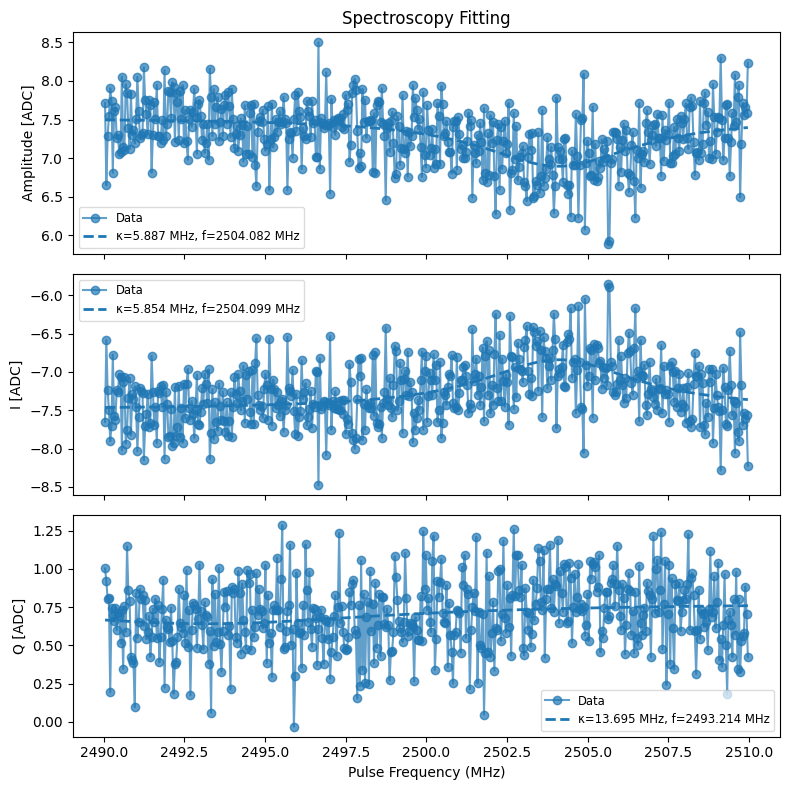

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-19-44_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-19-44_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


In [32]:
spec_analysis = meas.SpectroscopyFitting(#title='Readout Spectroscopy',
                                         data=f0g1spec.data, station=station)
spec_analysis.analyze()
spec_analysis.display()#[2545, 2450])

In [29]:
ramp_current_mA(dcflux, -0.05)
f0g1spec2 = do_pulse_probe_spec(
        config_thisrun      = config_thisrun,
        center          = 2550,
        span            = 200,
        expts           = 1000,
        reps                = 500,
        rounds              = 1,
        pulse_e             = False,
        prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
        postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
        sweep_other_param   = None,
        probe_pulse_param   = {
            'gain':           0.5,
            'length':         5.0,
            'freq':           None,
            'chan':           config_thisrun.hw.soc.dacs.manipulate_in.ch,
            'sigma':          0,
            'sigma_inc':      0,
            'ramp_sigma':     None,
            'ramp_sigma_inc': None,
            'phase':          0,
            'type':           'const',
        },
        analyze_and_display = False,
    )

Ramping 0.0000 → -0.0500 mA  (0.01 mA/s, ETA 5.0s)
Done. Current: -0.0500 mA
connected proxies, ns= <Pyro4.core.Proxy at 0x2855105b1d0; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 2450.0, 'step': 0.2, 'expts': 1000, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 0.5, 'length': 5.0, 'freq': <qick.asm_v2.QickParam object at 0x0000028550BB9450>, 'chan': 2, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const'}
pi_qubit_ge
pi_qubit_ef
Applied postpulse:  pi_qubit_ef
Applied postpulse:  pi_qubit_ge
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/500000 [00:00<?, ?it/s]

In [82]:
f_ge = config_thisrun.device.qubit.f_ge
f_ef = config_thisrun.device.qubit.f_ef
hfss_mode_freq = 6110 
f0g1_freq = f_ge + f_ef - hfss_mode_freq
print(f"f0g1 spec center: {f0g1_freq:.2f} MHz")
e0g1_freq = f_ge - hfss_mode_freq
print(f"e0g1 spec center: {e0g1_freq:.2f} MHz")

f0g1 spec center: 1188.52 MHz
e0g1 spec center: -2405.20 MHz


In [74]:
3700+3600

7300

## f0g1 dc sweep

In [116]:
def do_f0g1_dc_sweep(
    config_thisrun,
    dcflux,
    # current sweep
    current_start_mA        = -0.22,
    current_stop_mA         =  0.05,
    current_step_mA         =  0.003,
    ramp_speed_mA_per_s     =  0.01,
    settle_delay_s          =  0.1,
    # frequency axis
    center                  = 3000,
    span                    = 2000,
    expts                   = 2000,
    # per-point experiment params
    reps                    = 200,
    rounds                  = 1,
    prepulse                = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse               = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
    probe_gain              = 1.0,
    probe_length            = 0.2,
    probe_chan              = None,      # defaults to config_thisrun.hw.soc.dacs.qubit.ch
    # display
    cmap                    = 'RdBu_r',
    figsize                 = (12, 10),
    # retry
    max_retries             = 5,
    retry_delay_s           = 3.0,
):
    """
    DC current sweep of f0g1 spectroscopy with live 2D colorplot (amps, I, Q).
    Ramps current at ramp_speed_mA_per_s between points.
    Retries automatically on 'no free workers' CommunicationError.

    Parameters
    ----------
    config_thisrun      : AttrDict
    dcflux              : YokogawaGS200
    current_start_mA    : float — sweep start [mA]
    current_stop_mA     : float — sweep stop [mA]
    current_step_mA     : float — step size [mA]
    ramp_speed_mA_per_s : float — ramp rate between points [mA/s]
    settle_delay_s      : float — wait after reaching target current [s]
    center              : float — probe center frequency [MHz]
    span                : float — probe frequency span [MHz]
    expts               : int   — frequency points per spectrum
    reps                : int   — averages per frequency point
    rounds              : int   — software rounds
    prepulse            : dict  — prepulse dict
    postpulse           : dict  — postpulse dict
    probe_gain          : float — probe pulse gain
    probe_length        : float — probe pulse length [us]
    probe_chan          : int or None — DAC channel, defaults to qubit ch
    cmap                : str   — matplotlib colormap
    figsize             : tuple — figure size
    max_retries         : int   — max retry attempts on worker error
    retry_delay_s       : float — seconds to wait between retries

    Returns
    -------
    dict with keys:
        'currents'   : np.ndarray of current values [mA]
        'freq_array' : np.ndarray of frequency points [MHz]
        'amp_matrix' : 2D np.ndarray (n_currents x n_freqs)
        'i_matrix'   : 2D np.ndarray (n_currents x n_freqs)
        'q_matrix'   : 2D np.ndarray (n_currents x n_freqs)
        'pspecs'     : dict keyed by current value [mA] — raw ppspec objects (None if failed)
    """
    if probe_chan is None:
        probe_chan = config_thisrun.hw.soc.dacs.qubit.ch

    currents = np.arange(current_start_mA, current_stop_mA, current_step_mA)
    n_steps  = len(currents)
    print(f'DC sweep: {current_start_mA:.4f} → {current_stop_mA:.4f} mA, '
          f'step={current_step_mA:.4f} mA, n={n_steps}, '
          f'ramp speed={ramp_speed_mA_per_s} mA/s')

    # ramp to start
    ramp_current_mA(dcflux, current_start_mA, ramp_speed_mA_per_s)

    pspecs     = {}
    amp_matrix = None
    i_matrix   = None
    q_matrix   = None
    freq_array = None

    fig, axes = plt.subplots(3, 1, figsize=figsize)
    plt.ion()
    cbars = [None, None, None]

    try:
        for idx, cur_mA in enumerate(currents):
            set_current_mA(dcflux, cur_mA, ramp_speed_mA_per_s)
            time.sleep(settle_delay_s)
            print(f'\n[{idx+1}/{n_steps}]  current = {cur_mA:.4f} mA')

            # ── retry wrapper ─────────────────────────────────
            pspec = None
            for attempt in range(max_retries):
                try:
                    pspec = do_pulse_probe_spec(
                        config_thisrun      = config_thisrun,
                        center              = center,
                        span                = span,
                        expts               = expts,
                        reps                = reps,
                        rounds              = rounds,
                        pulse_e             = False,
                        prepulse            = prepulse,
                        postpulse           = postpulse,
                        sweep_other_param   = None,
                        probe_pulse_param   = {
                            'gain':           probe_gain,
                            'length':         probe_length,
                            'freq':           None,
                            'chan':           probe_chan,
                            'sigma':          0,
                            'sigma_inc':      0,
                            'ramp_sigma':     None,
                            'ramp_sigma_inc': None,
                            'phase':          0,
                            'type':           'const',
                        },
                        analyze_and_display = False,
                    )
                    time.sleep(60.0)
                    break  # success
                    

                except Exception as e:
                    if 'no free workers' in str(e) and attempt < max_retries - 1:
                        print(f'  Worker busy (attempt {attempt+1}/{max_retries}), '
                              f'retrying in {retry_delay_s}s...')
                        time.sleep(retry_delay_s)
                    else:
                        print(f'  Failed after {max_retries} attempts: {e}')
                        break

            pspecs[float(cur_mA)] = pspec

            # ── accumulate matrices ───────────────────────────
            if pspec is None:
                n_pts  = len(freq_array) if freq_array is not None else expts
                r_amps = np.full(n_pts, np.nan)
                r_avgi = np.full(n_pts, np.nan)
                r_avgq = np.full(n_pts, np.nan)
            else:
                freq_array = pspec.data['xpts']
                def _row(k):
                    r = np.array(pspec.data[k])
                    return r.flatten() if r.ndim > 1 else r
                r_amps = _row('amps')
                r_avgi = _row('avgi')
                r_avgq = _row('avgq')

            def _stack(mat, row):
                return row[np.newaxis, :] if mat is None else np.vstack([mat, row[np.newaxis, :]])

            amp_matrix = _stack(amp_matrix, r_amps)
            i_matrix   = _stack(i_matrix,   r_avgi)
            q_matrix   = _stack(q_matrix,   r_avgq)

            # ── live plot ─────────────────────────────────────
            for ax in axes:
                ax.cla()

            filled          = amp_matrix.shape[0]
            currents_so_far = currents[:filled]
            matrices_live   = [amp_matrix, i_matrix, q_matrix]
            titles_live     = ['Amplitude', 'I', 'Q']

            for j, (ax, mat, title) in enumerate(zip(axes, matrices_live, titles_live)):
                im = ax.pcolormesh(freq_array, currents_so_far, mat,
                                   shading='auto', cmap=cmap)
                ax.set_xlabel('Frequency (MHz)', fontsize=11)
                ax.set_title(f'{title}  ({filled}/{n_steps})', fontsize=11)
                if cbars[j] is None:
                    cbars[j] = fig.colorbar(im, ax=ax, label=title,
                                            fraction=0.046, pad=0.04)
                else:
                    cbars[j].update_normal(im)

            axes[0].set_ylabel('DC Current (mA)', fontsize=11)
            axes[1].set_ylabel('DC Current (mA)', fontsize=11)
            axes[2].set_ylabel('DC Current (mA)', fontsize=11)

            fig.tight_layout()
            clear_output(wait=True)
            display(fig)

    except KeyboardInterrupt:
        print('\nSweep interrupted by user.')

    finally:
        dcflux.set_output(False)
        print('Yoko output OFF.')

    plt.ioff()
    n_success = sum(1 for sp in pspecs.values() if sp is not None)
    print(f'\nSweep done. {n_success}/{n_steps} points acquired successfully.')

    return {
        'currents'   : currents[:len(pspecs)],
        'freq_array' : freq_array,
        'amp_matrix' : amp_matrix,
        'i_matrix'   : i_matrix,
        'q_matrix'   : q_matrix,
        'pspecs'     : pspecs,
    }


def replot_f0g1_dc_sweep(result, cmap='RdBu_r', clim=None, figsize=(12, 10)):
    """
    Re-plot a completed DC sweep showing amplitude, I and Q.

    Parameters
    ----------
    result  : dict returned by do_f0g1_dc_sweep
    cmap    : str   — colormap
    clim    : dict, tuple, or None — color limits, e.g.
                  {'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)}
              or a single tuple applied to all, or None for auto
    figsize : tuple
    """
    currents   = result['currents']
    freq_array = result['freq_array']
    matrices   = [result['amp_matrix'], result['i_matrix'], result['q_matrix']]
    keys       = ['amps', 'avgi', 'avgq']
    titles     = ['Amplitude', 'I', 'Q']

    if clim is None:
        clims = {k: None for k in keys}
    elif isinstance(clim, tuple):
        clims = {k: clim for k in keys}
    else:
        clims = clim

    fig, axes = plt.subplots(3, 1, figsize=figsize)
    for ax, mat, key, title in zip(axes, matrices, keys, titles):
        im = ax.pcolormesh(freq_array, currents, mat, shading='auto', cmap=cmap)
        if clims.get(key) is not None:
            im.set_clim(*clims[key])
        fig.colorbar(im, ax=ax, label=title, fraction=0.046, pad=0.04)
        ax.set_xlabel('Frequency (MHz)', fontsize=11)
        ax.set_ylabel('DC Current (mA)', fontsize=11)
        ax.set_title(title, fontsize=11)

    fig.tight_layout()
    plt.show()
    return fig

In [117]:
(0.25/0.01)*4

100.0

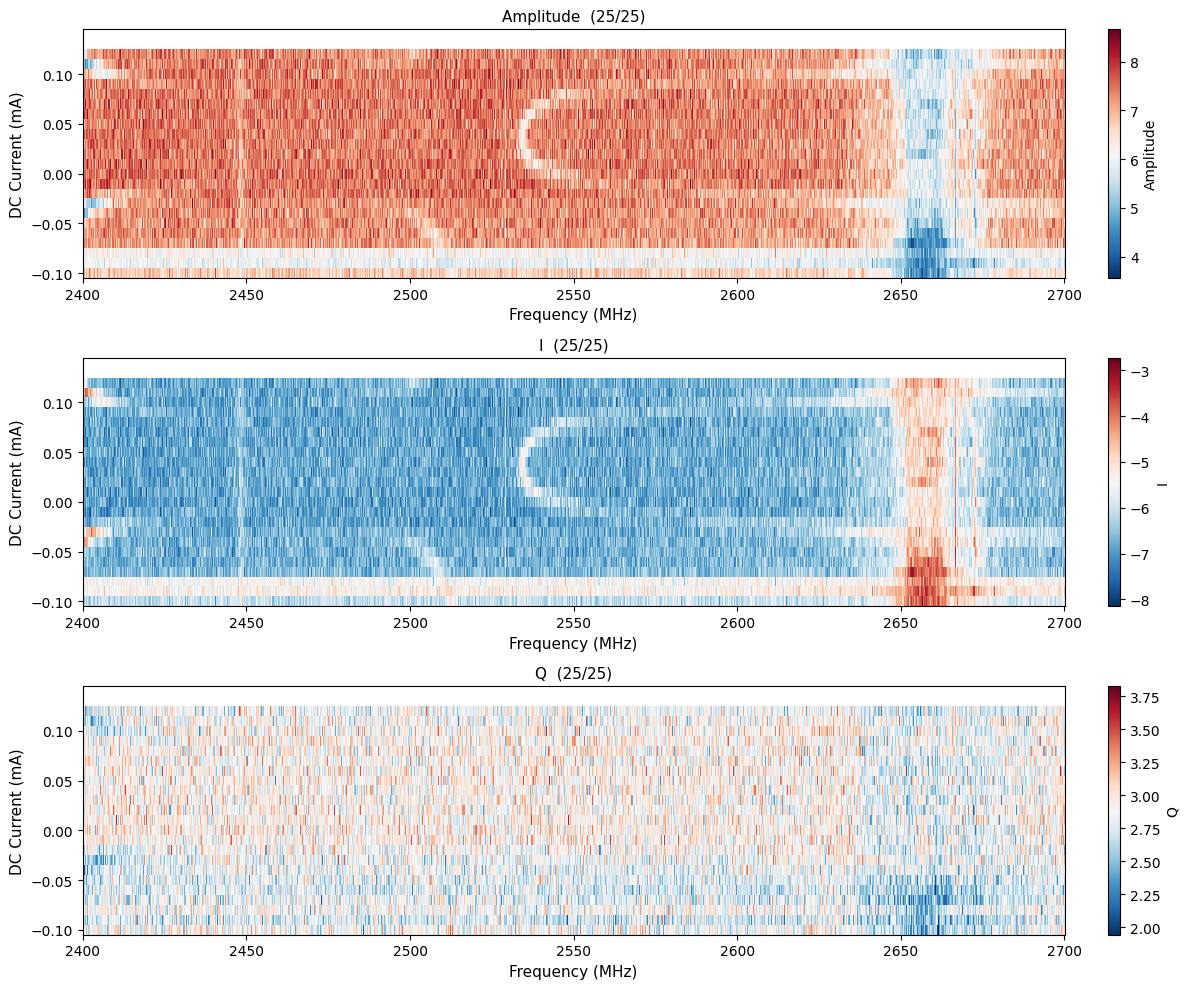

Yoko output OFF.

Sweep done. 23/25 points acquired successfully.


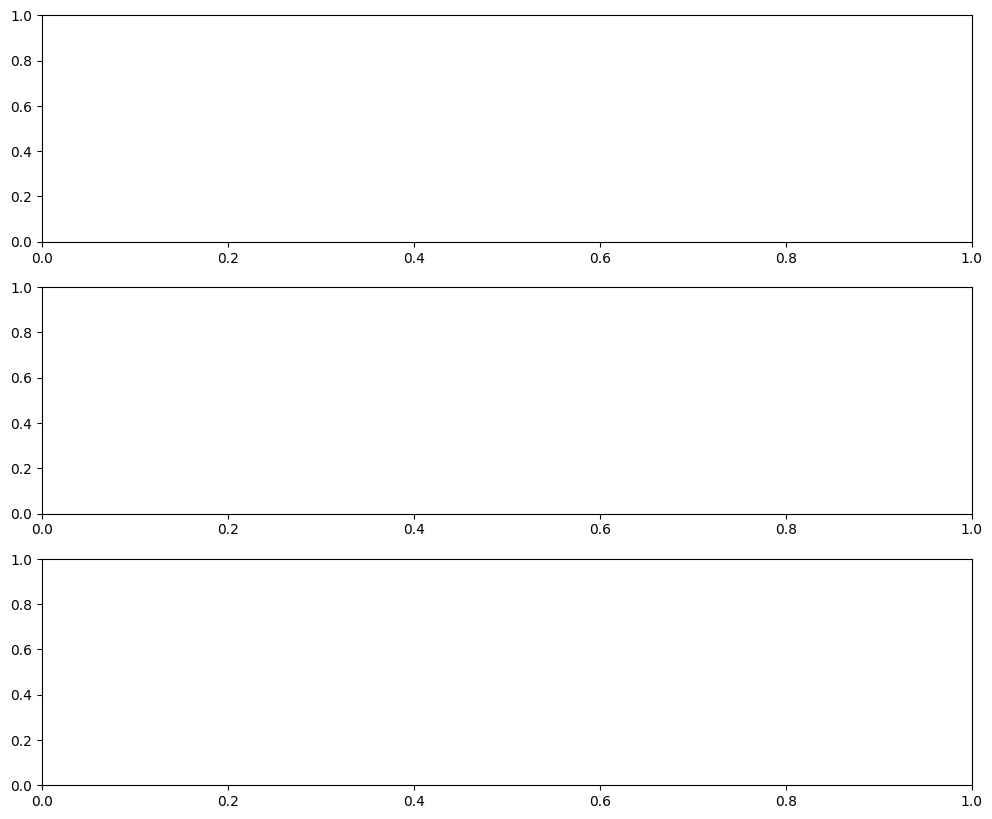

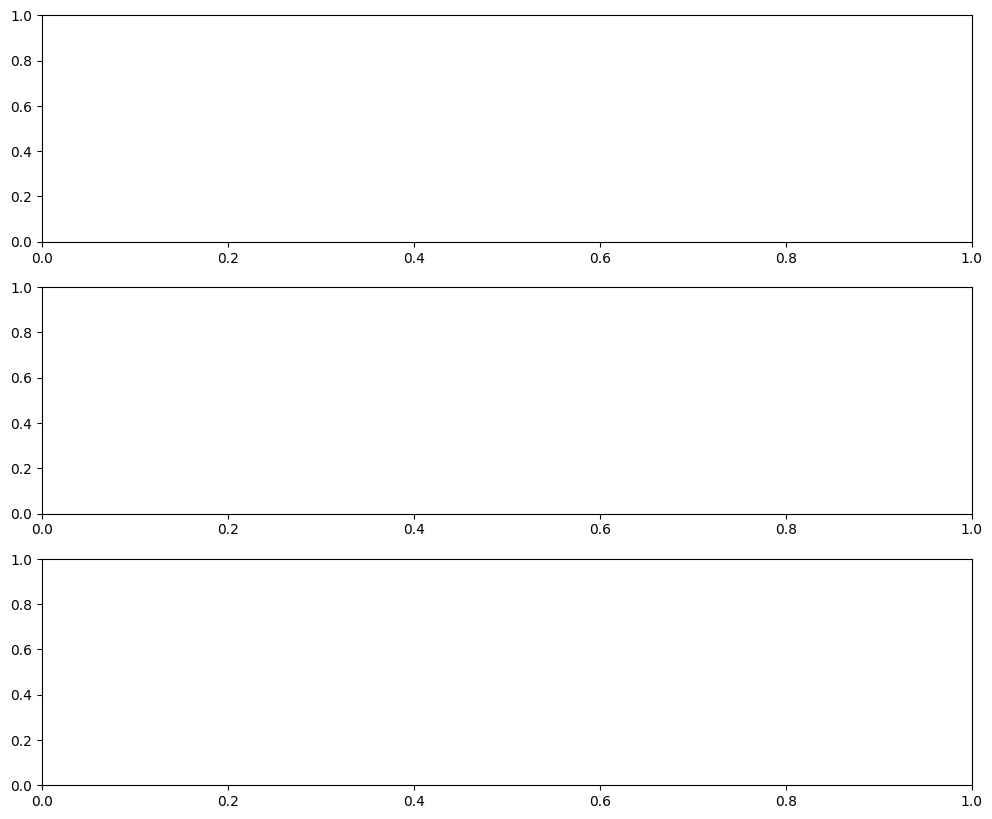

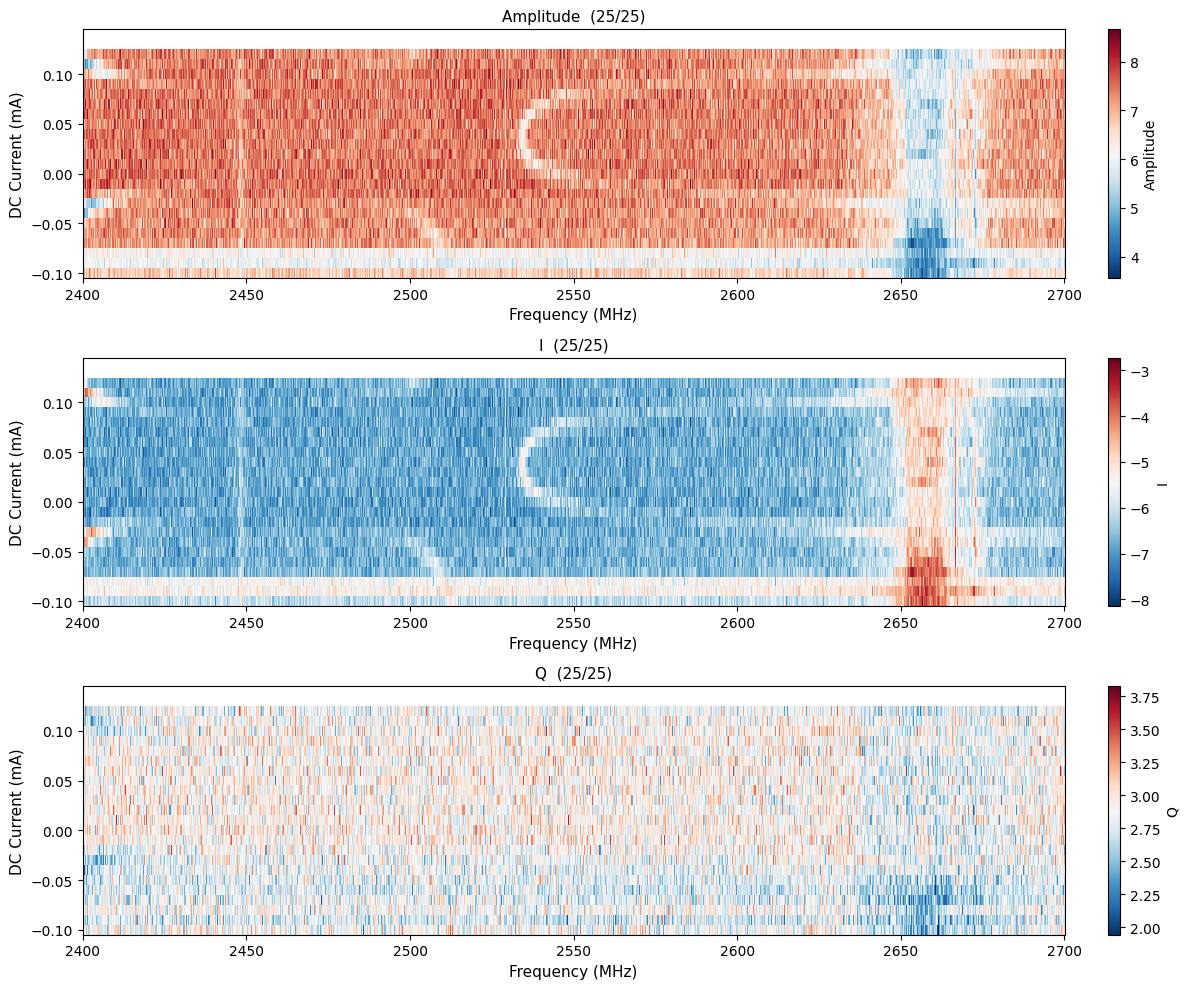

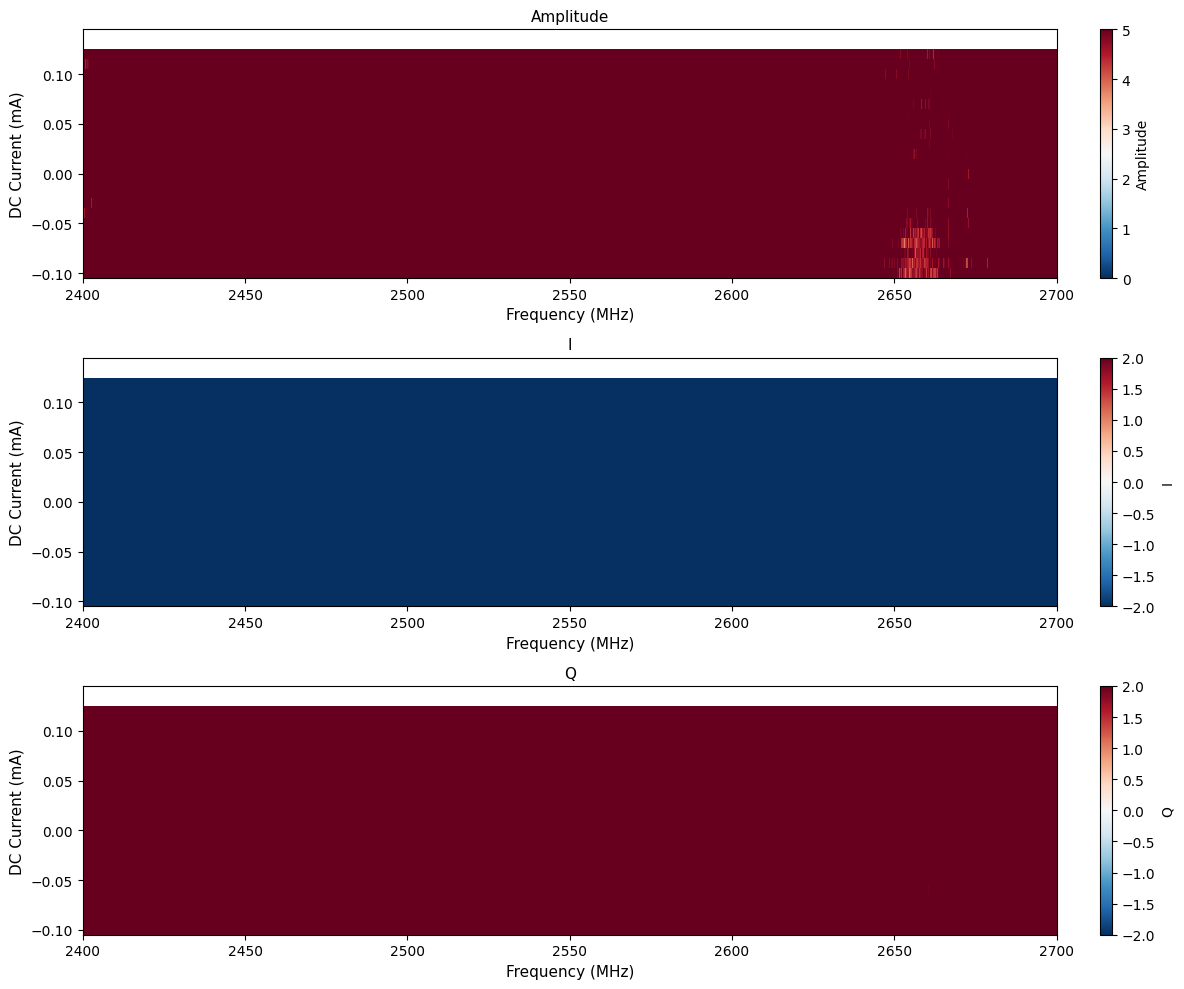

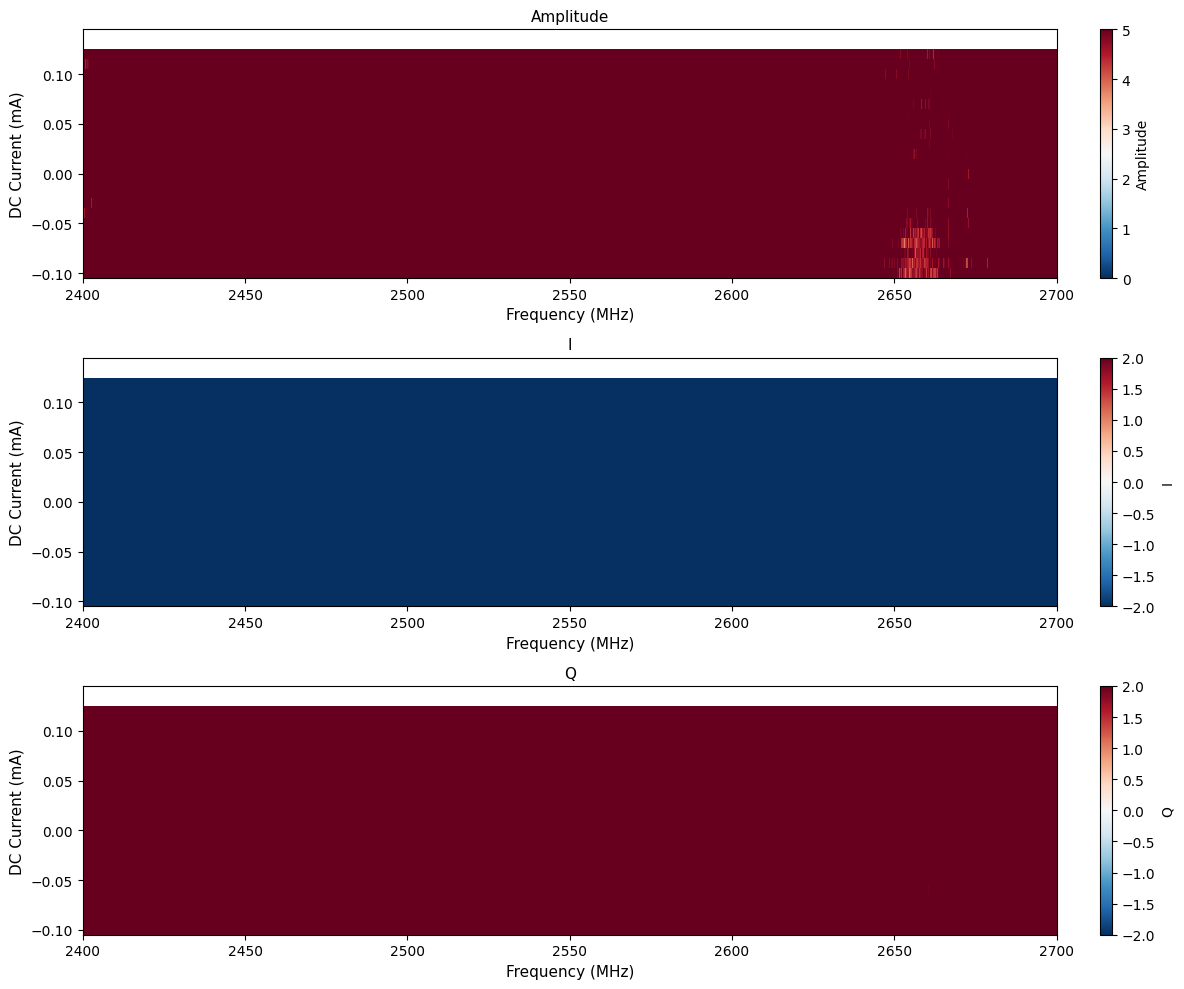

In [118]:
# from yoko_helpers import ramp_current_mA
from slab.instruments import YokogawaGS200

dcflux = YokogawaGS200(address='10.108.30.37')
dcflux.set_output(True)
dcflux.set_mode('current')

result = do_f0g1_dc_sweep(
    config_thisrun      = config_thisrun,
    dcflux              = dcflux,
    current_start_mA    = -0.10,
    current_stop_mA     =  0.15,
    current_step_mA     =  0.01,
    ramp_speed_mA_per_s =  0.01,    # 0.01 mA/s between points
    settle_delay_s      =  0.1,
    center              = 2550,
    span                = 300,
    expts               = 2000,
    reps                = 300,
    probe_gain          = 1.0,
    probe_length        = 5.0,
    probe_chan          = config_thisrun.hw.soc.dacs.qubit.ch,
    prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
)

# re-plot with adjusted colorscale
replot_f0g1_dc_sweep(result, clim={'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)})

## f0g1 power sweep 

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


def do_f0g1_power_sweep(
    config_thisrun,
    # frequency axis
    center              = 3000,
    span                = 2000,
    expts               = 2000,
    # gain sweep
    gains               = None,     # pass an array, or use gain_start/stop/n
    gain_start          = 0.01,
    gain_stop           = 1.0,
    gain_n              = 20,
    # per-point experiment params
    reps                = 200,
    rounds              = 1,
    prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
    probe_length        = 0.2,
    probe_chan          = None,      # defaults to config_thisrun.hw.soc.dacs.qubit.ch
    # display
    plot_key            = 'avgi',   # 'amps' | 'avgi' | 'avgq'
    cmap                = 'RdBu_r',
    figsize             = (12, 10),
    # retry
    max_retries         = 5,
    retry_delay_s       = 3.0,
):
    """
    Power sweep of f0g1 spectroscopy with live 2D colorplot.
    Retries automatically on 'no free workers' CommunicationError.

    Parameters
    ----------
    config_thisrun  : AttrDict
    center          : float — probe center frequency [MHz]
    span            : float — probe frequency span [MHz]
    expts           : int   — frequency points per spectrum
    gains           : array-like or None — explicit gain array.
                      If None, uses np.linspace(gain_start, gain_stop, gain_n)
    gain_start      : float — sweep start gain (used if gains=None)
    gain_stop       : float — sweep stop gain  (used if gains=None)
    gain_n          : int   — number of gain points (used if gains=None)
    reps            : int   — averages per frequency point
    rounds          : int   — software rounds
    prepulse        : dict  — prepulse dict
    postpulse       : dict  — postpulse dict
    probe_length    : float — probe pulse length [us]
    probe_chan      : int or None — DAC channel. Defaults to qubit ch from config.
    plot_key        : str   — which signal to plot: 'amps', 'avgi', 'avgq'
    cmap            : str   — matplotlib colormap
    figsize         : tuple — figure size
    max_retries     : int   — max retry attempts on worker error
    retry_delay_s   : float — seconds to wait between retries

    Returns
    -------
    dict with keys:
        'gains'      : np.ndarray of gain values
        'freq_array' : np.ndarray of frequency points [MHz]
        'amp_matrix' : 2D np.ndarray (n_gains x n_freqs), NaN for failed points
        'pspecs'     : dict keyed by gain value — raw ppspec objects (None if failed)
    """
    if gains is None:
        gains = np.linspace(gain_start, gain_stop, gain_n)
    gains = np.asarray(gains)

    if probe_chan is None:
        probe_chan = config_thisrun.hw.soc.dacs.qubit.ch

    n_gains    = len(gains)
    pspecs     = {}
    amp_matrix  = None   # amps
    i_matrix    = None   # avgi
    q_matrix    = None   # avgq
    freq_array  = None

    fig, axes = plt.subplots(3, 1, figsize=figsize)#, sharex=True)
    plt.ion()
    cbars = [None, None, None]

    for idx, gain in enumerate(gains):
        print(f'\n[{idx+1}/{n_gains}]  gain = {gain:.4f}')

        # ── retry wrapper ─────────────────────────────────────
        pspec = None
        for attempt in range(max_retries):
            try:
                pspec = do_pulse_probe_spec(
                    config_thisrun      = config_thisrun,
                    center              = center,
                    span                = span,
                    expts               = expts,
                    reps                = reps,
                    rounds              = rounds,
                    pulse_e             = False,
                    prepulse            = prepulse,
                    postpulse           = postpulse,
                    sweep_other_param   = None,
                    probe_pulse_param   = {
                        'gain':           gain,
                        'length':         probe_length,
                        'freq':           None,
                        'chan':           probe_chan,
                        'sigma':          0,
                        'sigma_inc':      0,
                        'ramp_sigma':     None,
                        'ramp_sigma_inc': None,
                        'phase':          0,
                        'type':           'const',
                    },
                    analyze_and_display = False,
                )
                time.sleep(3)
                break  # success

            except Exception as e:
                if 'no free workers' in str(e) and attempt < max_retries - 1:
                    print(f'  Worker busy (attempt {attempt+1}/{max_retries}), '
                          f'retrying in {retry_delay_s}s...')
                    time.sleep(retry_delay_s)
                else:
                    print(f'  Failed after {max_retries} attempts: {e}')
                    break

        pspecs[float(gain)] = pspec

        # ── accumulate matrices ───────────────────────────────
        if pspec is None:
            n_pts  = len(freq_array) if freq_array is not None else expts
            r_amps = np.full(n_pts, np.nan)
            r_avgi = np.full(n_pts, np.nan)
            r_avgq = np.full(n_pts, np.nan)
        else:
            freq_array = pspec.data['xpts']
            def _row(k):
                r = np.array(pspec.data[k])
                return r.flatten() if r.ndim > 1 else r
            r_amps = _row('amps')
            r_avgi = _row('avgi')
            r_avgq = _row('avgq')

        def _stack(mat, row):
            return row[np.newaxis, :] if mat is None else np.vstack([mat, row[np.newaxis, :]])

        amp_matrix = _stack(amp_matrix, r_amps)
        i_matrix   = _stack(i_matrix,   r_avgi)
        q_matrix   = _stack(q_matrix,   r_avgq)

        # ── live plot ─────────────────────────────────────────
        for ax in axes:
            ax.cla()

        filled       = amp_matrix.shape[0]
        gains_so_far = gains[:filled]
        matrices_live = [amp_matrix, i_matrix, q_matrix]
        titles_live   = ['Amplitude', 'I', 'Q']

        for j, (ax, mat, title) in enumerate(zip(axes, matrices_live, titles_live)):
            im = ax.pcolormesh(freq_array, gains_so_far, mat,
                               shading='auto', cmap=cmap)
            ax.set_xlabel('Frequency (MHz)', fontsize=11)
            ax.set_title(f'{title}  ({filled}/{n_gains})', fontsize=11)
            if cbars[j] is None:
                cbars[j] = fig.colorbar(im, ax=ax, label=title,
                                        fraction=0.046, pad=0.04)
            else:
                cbars[j].update_normal(im)

        axes[0].set_ylabel('Probe gain', fontsize=11)

        fig.tight_layout()
        clear_output(wait=True)
        display(fig)

    plt.ioff()
    n_success = sum(1 for sp in pspecs.values() if sp is not None)
    print(f'\nSweep done. {n_success}/{n_gains} points acquired successfully.')

    return {
        'gains'      : gains,
        'freq_array' : freq_array,
        'amp_matrix' : amp_matrix,
        'i_matrix'   : i_matrix,
        'q_matrix'   : q_matrix,
        'pspecs'     : pspecs,
    }


def replot_f0g1_power_sweep(result, cmap='RdBu_r', clim=None, figsize=(16, 12)):
    """
    Re-plot a completed power sweep showing amplitude, I and Q side by side.
    Builds the three matrices from the stored pspecs on the fly.

    Parameters
    ----------
    result   : dict returned by do_f0g1_power_sweep
    cmap     : str   — colormap (applied to all three panels)
    clim     : dict or None — per-panel color limits, e.g.
                   {'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)}
               or a single tuple applied to all, e.g. (-2, 2)
               or None for auto
    figsize  : tuple
    """
    gains      = result['gains']
    freq_array = result['freq_array']
    pspecs     = result['pspecs']
    keys       = ['amps', 'avgi', 'avgq']
    titles     = ['Amplitude', 'I', 'Q']

    # build one matrix per signal
    matrices = {k: [] for k in keys}
    valid_gains = []
    for gain in gains:
        sp = pspecs.get(float(gain))
        if sp is None:
            row = np.full(len(freq_array), np.nan)
            for k in keys:
                matrices[k].append(row)
        else:
            valid_gains.append(gain)
            for k in keys:
                row = np.array(sp.data[k])
                if row.ndim > 1:
                    row = row.flatten()
                matrices[k].append(row)
    for k in keys:
        matrices[k] = np.vstack(matrices[k])

    # normalise clim input
    if clim is None:
        clims = {k: None for k in keys}
    elif isinstance(clim, tuple):
        clims = {k: clim for k in keys}
    else:
        clims = clim  # dict provided directly

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    for ax, k, title in zip(axes, keys, titles):
        im = ax.pcolormesh(freq_array, gains, matrices[k],
                           shading='auto', cmap=cmap)
        if clims.get(k) is not None:
            im.set_clim(*clims[k])
        fig.colorbar(im, ax=ax, label=title, fraction=0.046, pad=0.04)
        ax.set_xlabel('Frequency (MHz)', fontsize=11)
        ax.set_title(f'F0G1 power sweep — {title}', fontsize=11)

    axes[0].set_ylabel('Probe gain', fontsize=11)
    fig.tight_layout()
    plt.show()
    return fig, matrices

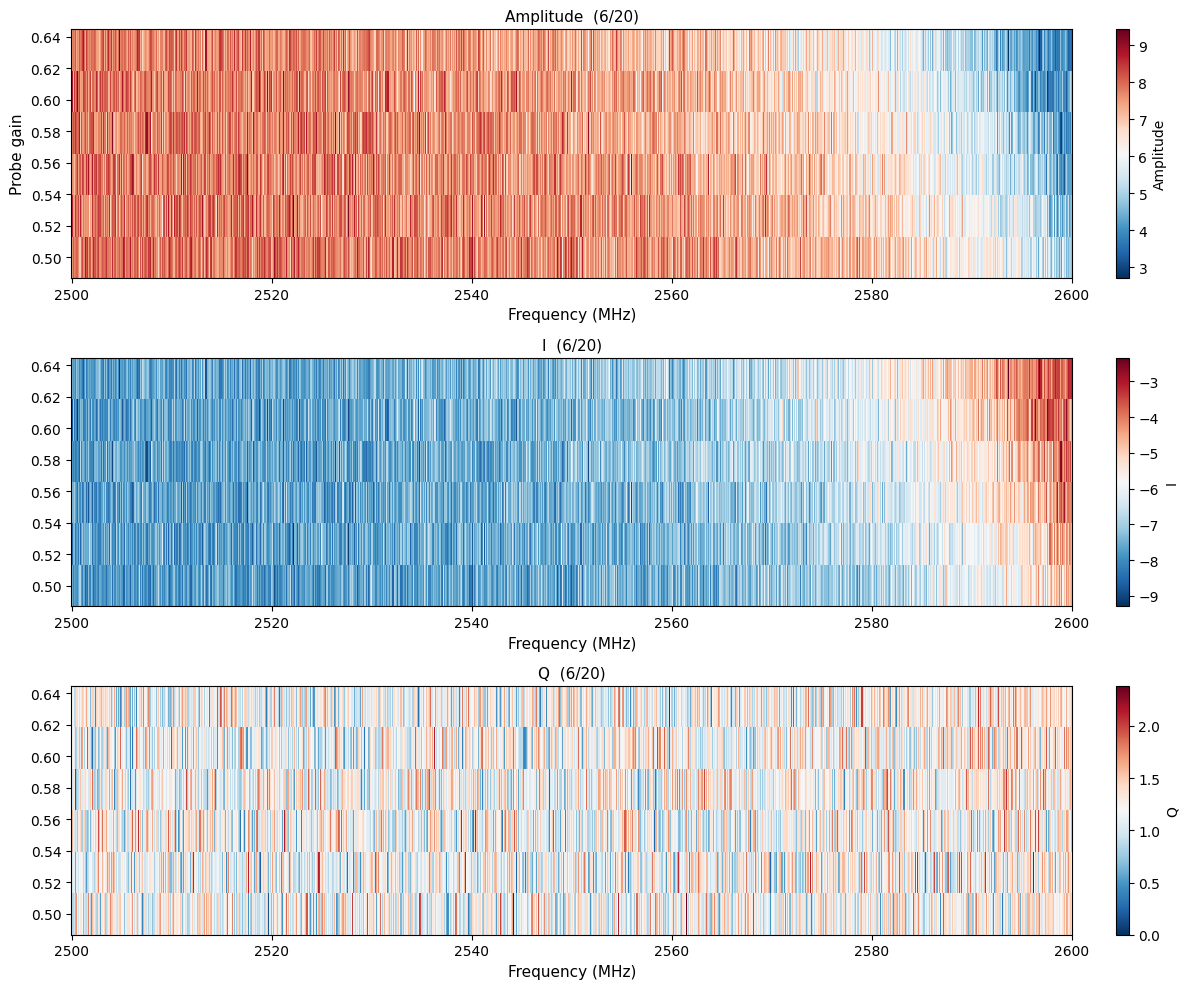


[7/20]  gain = 0.6579
connected proxies, ns= <Pyro4.core.Proxy at 0x2305b568710; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 2500.0, 'step': 0.1, 'expts': 1000, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': np.float64(0.6578947368421053), 'length': 1.0, 'freq': <qick.asm_v2.QickParam object at 0x00000230601216D0>, 'chan': 2, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const'}
pi_qubit_ge
delayiong after prepulse pi_qubit_ge
pi_qubit_ef
delayiong after prepulse pi_qubit_ef
Applied postpulse:  pi_qubit_ef
Applied postpulse:  pi_qubit_ge
pulsing resonator
triggering re

  0%|          | 0/100000 [00:00<?, ?it/s]

KeyboardInterrupt: 

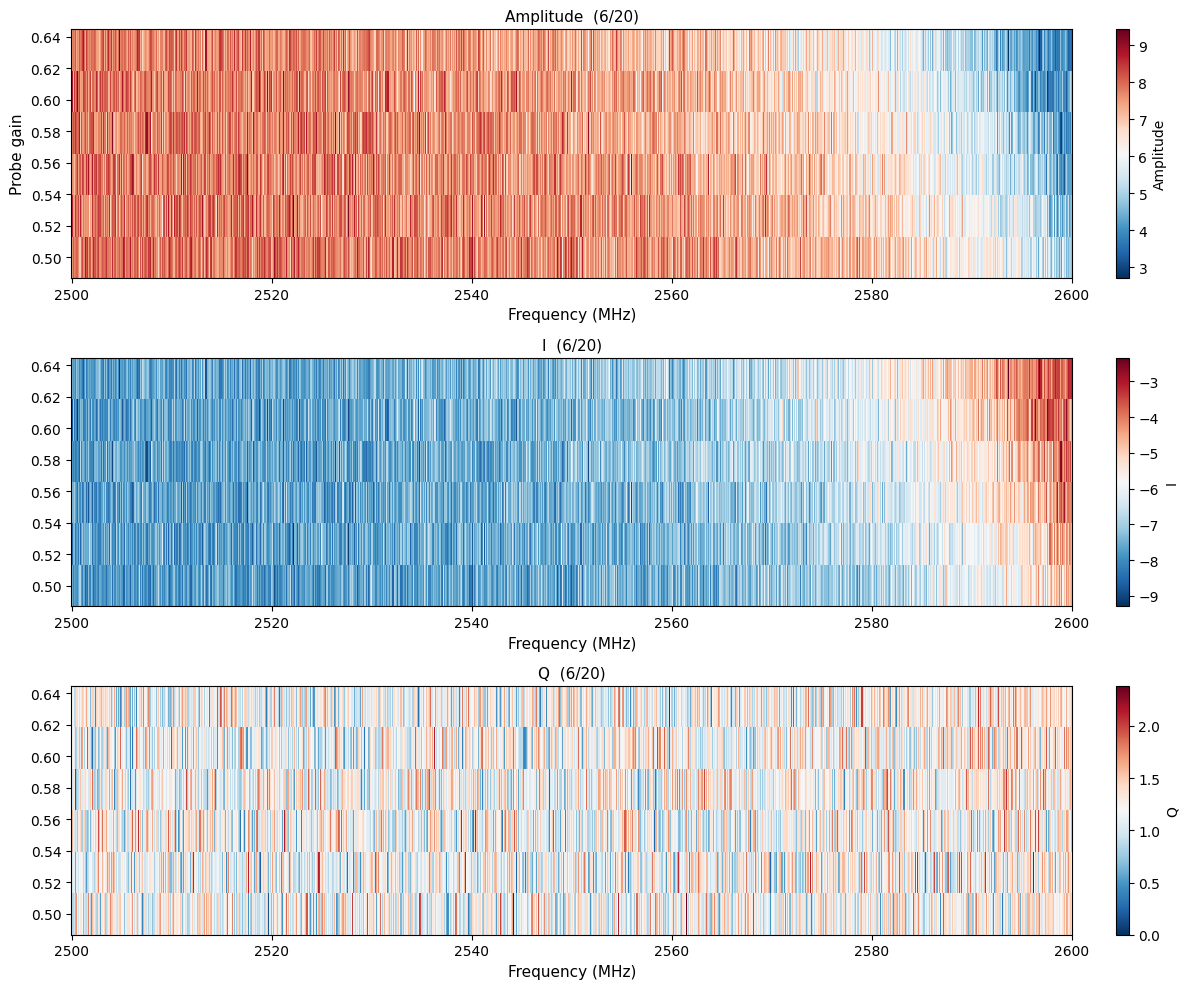

In [11]:
result = do_f0g1_power_sweep(
    config_thisrun  = config_thisrun,
    center          = 2550,
    span            = 100,
    expts           = 1000,
    gain_start      = 0.5,
    gain_stop       = 1.0,
    gain_n          = 20,
    reps            = 100,
    rounds          = 1,
    prepulse        = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse       = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
    probe_length    = 1.0,
    probe_chan      = config_thisrun.hw.soc.dacs.manipulate_in.ch,
    plot_key        = 'avgi',
    max_retries     = 5,
    retry_delay_s   = 3.0,
)



In [101]:
3700+3600 - 4800

2500

In [ ]:
# for man_mode_no in man_modes:
#     f0g1spec = do_pulse_probe_spec(
#         config_thisrun      = config_thisrun,
#         center              = ds_thisrun.get_freq('M' + str(man_mode_no)),
#         span                = 100,
#         expts               = 200,
#         reps                = 200,
#         rounds              = 1,
#         pulse_e             = False,
#         prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
#         postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
#         sweep_other_param   = None,
#         probe_pulse_param   = {
#             'gain':           0.01,
#             'length':         0.2,
#             'freq':           None,
#             'chan':           config_thisrun.hw.soc.dacs.qubit.ch,
#             'sigma':          0,
#             'sigma_inc':      0,
#             'ramp_sigma':     None,
#             'ramp_sigma_inc': None,
#             'phase':          0,
#             'type':           'const',
#         },
#         analyze_and_display = True,
#     )
    # Uncomment to update if peak is clear:
    # ds_thisrun.update_freq('M' + str(man_mode_no), f0g1spec.data['fit_avgi'][2])
    # print(f'Updated M{man_mode_no} freq to {f0g1spec.data["fit_avgi"][2]:.3f} MHz')

## f0g1 length sweep 

In [35]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


def do_f0g1_length_sweep(
    config_thisrun,
    # frequency axis
    center              = 3000,
    span                = 2000,
    expts               = 2000,
    # length sweep
    lengths             = None,     # pass an array, or use length_start/stop/n
    length_start        = 0.01,
    length_stop         = 1.0,
    length_n            = 20,
    # per-point experiment params
    reps                = 200,
    rounds              = 1,
    prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
    probe_gain          = 1.0,
    probe_chan          = None,      # defaults to config_thisrun.hw.soc.dacs.qubit.ch
    # display
    cmap                = 'RdBu_r',
    figsize             = (12, 10),
    # retry
    max_retries         = 5,
    retry_delay_s       = 3.0,
):
    """
    Length sweep of f0g1 spectroscopy with live 2D colorplot (amps, I, Q).
    Retries automatically on 'no free workers' CommunicationError.

    Parameters
    ----------
    config_thisrun  : AttrDict
    center          : float — probe center frequency [MHz]
    span            : float — probe frequency span [MHz]
    expts           : int   — frequency points per spectrum
    lengths         : array-like or None — explicit length array [us].
                      If None, uses np.linspace(length_start, length_stop, length_n)
    length_start    : float — sweep start length [us] (used if lengths=None)
    length_stop     : float — sweep stop length [us]  (used if lengths=None)
    length_n        : int   — number of length points  (used if lengths=None)
    reps            : int   — averages per frequency point
    rounds          : int   — software rounds
    prepulse        : dict  — prepulse dict
    postpulse       : dict  — postpulse dict
    probe_gain      : float — probe pulse gain
    probe_chan      : int or None — DAC channel. Defaults to qubit ch from config.
    cmap            : str   — matplotlib colormap
    figsize         : tuple — figure size
    max_retries     : int   — max retry attempts on worker error
    retry_delay_s   : float — seconds to wait between retries

    Returns
    -------
    dict with keys:
        'lengths'    : np.ndarray of length values [us]
        'freq_array' : np.ndarray of frequency points [MHz]
        'amp_matrix' : 2D np.ndarray (n_lengths x n_freqs)
        'i_matrix'   : 2D np.ndarray (n_lengths x n_freqs)
        'q_matrix'   : 2D np.ndarray (n_lengths x n_freqs)
        'pspecs'     : dict keyed by length value [us] — raw ppspec objects (None if failed)
    """
    if lengths is None:
        lengths = np.linspace(length_start, length_stop, length_n)
    lengths = np.asarray(lengths)

    if probe_chan is None:
        probe_chan = config_thisrun.hw.soc.dacs.qubit.ch

    n_lengths  = len(lengths)
    pspecs     = {}
    amp_matrix = None
    i_matrix   = None
    q_matrix   = None
    freq_array = None

    fig, axes = plt.subplots(3, 1, figsize=figsize)
    plt.ion()
    cbars = [None, None, None]

    for idx, length in enumerate(lengths):
        print(f'\n[{idx+1}/{n_lengths}]  length = {length:.4f} us')

        # ── retry wrapper ─────────────────────────────────────
        pspec = None
        for attempt in range(max_retries):
            try:
                pspec = do_pulse_probe_spec(
                    config_thisrun      = config_thisrun,
                    center              = center,
                    span                = span,
                    expts               = expts,
                    reps                = reps,
                    rounds              = rounds,
                    pulse_e             = False,
                    prepulse            = prepulse,
                    postpulse           = postpulse,
                    sweep_other_param   = None,
                    probe_pulse_param   = {
                        'gain':           probe_gain,
                        'length':         length,
                        'freq':           None,
                        'chan':           probe_chan,
                        'sigma':          0,
                        'sigma_inc':      0,
                        'ramp_sigma':     None,
                        'ramp_sigma_inc': None,
                        'phase':          0,
                        'type':           'const',
                    },
                    analyze_and_display = False,
                )
                break  # success

            except Exception as e:
                if 'no free workers' in str(e) and attempt < max_retries - 1:
                    print(f'  Worker busy (attempt {attempt+1}/{max_retries}), '
                          f'retrying in {retry_delay_s}s...')
                    time.sleep(retry_delay_s)
                else:
                    print(f'  Failed after {max_retries} attempts: {e}')
                    break

        pspecs[float(length)] = pspec

        # ── accumulate matrices ───────────────────────────────
        if pspec is None:
            n_pts  = len(freq_array) if freq_array is not None else expts
            r_amps = np.full(n_pts, np.nan)
            r_avgi = np.full(n_pts, np.nan)
            r_avgq = np.full(n_pts, np.nan)
        else:
            freq_array = pspec.data['xpts']
            def _row(k):
                r = np.array(pspec.data[k])
                return r.flatten() if r.ndim > 1 else r
            r_amps = _row('amps')
            r_avgi = _row('avgi')
            r_avgq = _row('avgq')

        def _stack(mat, row):
            return row[np.newaxis, :] if mat is None else np.vstack([mat, row[np.newaxis, :]])

        amp_matrix = _stack(amp_matrix, r_amps)
        i_matrix   = _stack(i_matrix,   r_avgi)
        q_matrix   = _stack(q_matrix,   r_avgq)

        # ── live plot ─────────────────────────────────────────
        for ax in axes:
            ax.cla()

        filled          = amp_matrix.shape[0]
        lengths_so_far  = lengths[:filled]
        matrices_live   = [amp_matrix, i_matrix, q_matrix]
        titles_live     = ['Amplitude', 'I', 'Q']

        for j, (ax, mat, title) in enumerate(zip(axes, matrices_live, titles_live)):
            im = ax.pcolormesh(freq_array, lengths_so_far, mat,
                               shading='auto', cmap=cmap)
            ax.set_xlabel('Frequency (MHz)', fontsize=11)
            ax.set_ylabel('Probe length (us)', fontsize=11)
            ax.set_title(f'{title}  ({filled}/{n_lengths})', fontsize=11)
            if cbars[j] is None:
                cbars[j] = fig.colorbar(im, ax=ax, label=title,
                                        fraction=0.046, pad=0.04)
            else:
                cbars[j].update_normal(im)

        fig.tight_layout()
        clear_output(wait=True)
        display(fig)

    plt.ioff()
    n_success = sum(1 for sp in pspecs.values() if sp is not None)
    print(f'\nSweep done. {n_success}/{n_lengths} points acquired successfully.')

    return {
        'lengths'    : lengths,
        'freq_array' : freq_array,
        'amp_matrix' : amp_matrix,
        'i_matrix'   : i_matrix,
        'q_matrix'   : q_matrix,
        'pspecs'     : pspecs,
    }


def replot_f0g1_length_sweep(result, cmap='RdBu_r', clim=None, figsize=(16, 6)):
    """
    Re-plot a completed length sweep showing amplitude, I and Q side by side.

    Parameters
    ----------
    result  : dict returned by do_f0g1_length_sweep
    cmap    : str   — colormap
    clim    : dict, tuple, or None — color limits, e.g.
                  {'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)}
              or a single tuple applied to all, or None for auto
    figsize : tuple
    """
    lengths    = result['lengths']
    freq_array = result['freq_array']
    matrices   = [result['amp_matrix'], result['i_matrix'], result['q_matrix']]
    keys       = ['amps', 'avgi', 'avgq']
    titles     = ['Amplitude', 'I', 'Q']

    if clim is None:
        clims = {k: None for k in keys}
    elif isinstance(clim, tuple):
        clims = {k: clim for k in keys}
    else:
        clims = clim

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, mat, key, title in zip(axes, matrices, keys, titles):
        im = ax.pcolormesh(freq_array, lengths, mat, shading='auto', cmap=cmap)
        if clims.get(key) is not None:
            im.set_clim(*clims[key])
        fig.colorbar(im, ax=ax, label=title, fraction=0.046, pad=0.04)
        ax.set_xlabel('Frequency (MHz)', fontsize=11)
        ax.set_title(f'F0G1 length sweep — {title}', fontsize=11)

    axes[0].set_ylabel('Probe length (us)', fontsize=11)
    fig.tight_layout()
    plt.show()
    return fig

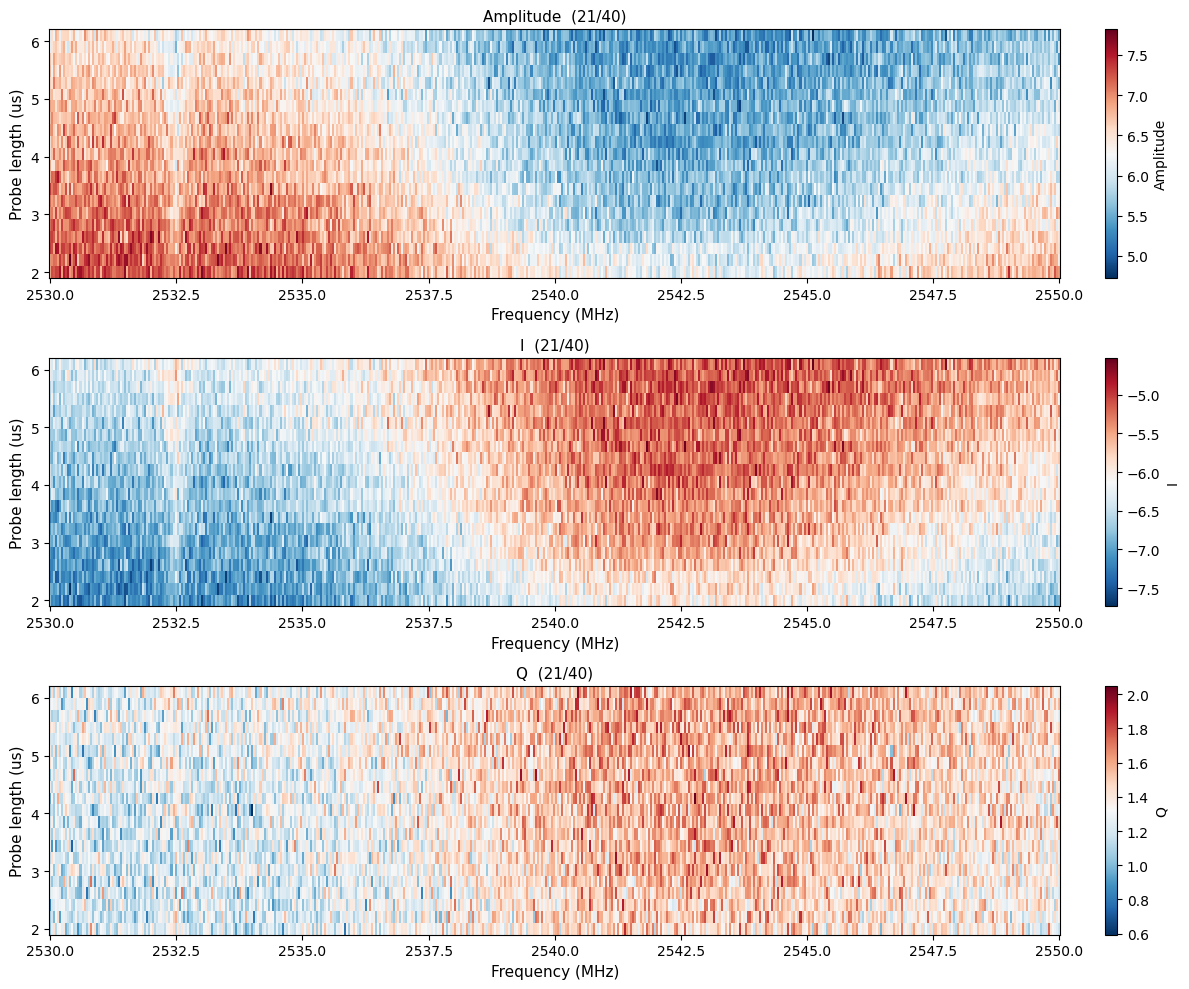


[22/40]  length = 6.3077 us
connected proxies, ns= <Pyro4.core.Proxy at 0x23063cb5490; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 2530.0, 'step': 0.04, 'expts': 500, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 1.0, 'length': np.float64(6.3076923076923075), 'freq': <qick.asm_v2.QickParam object at 0x00000230651A5ED0>, 'chan': 2, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const'}
pi_qubit_ge
pi_qubit_ef
Applied postpulse:  pi_qubit_ef
Applied postpulse:  pi_qubit_ge
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/250000 [00:00<?, ?it/s]

KeyboardInterrupt: 

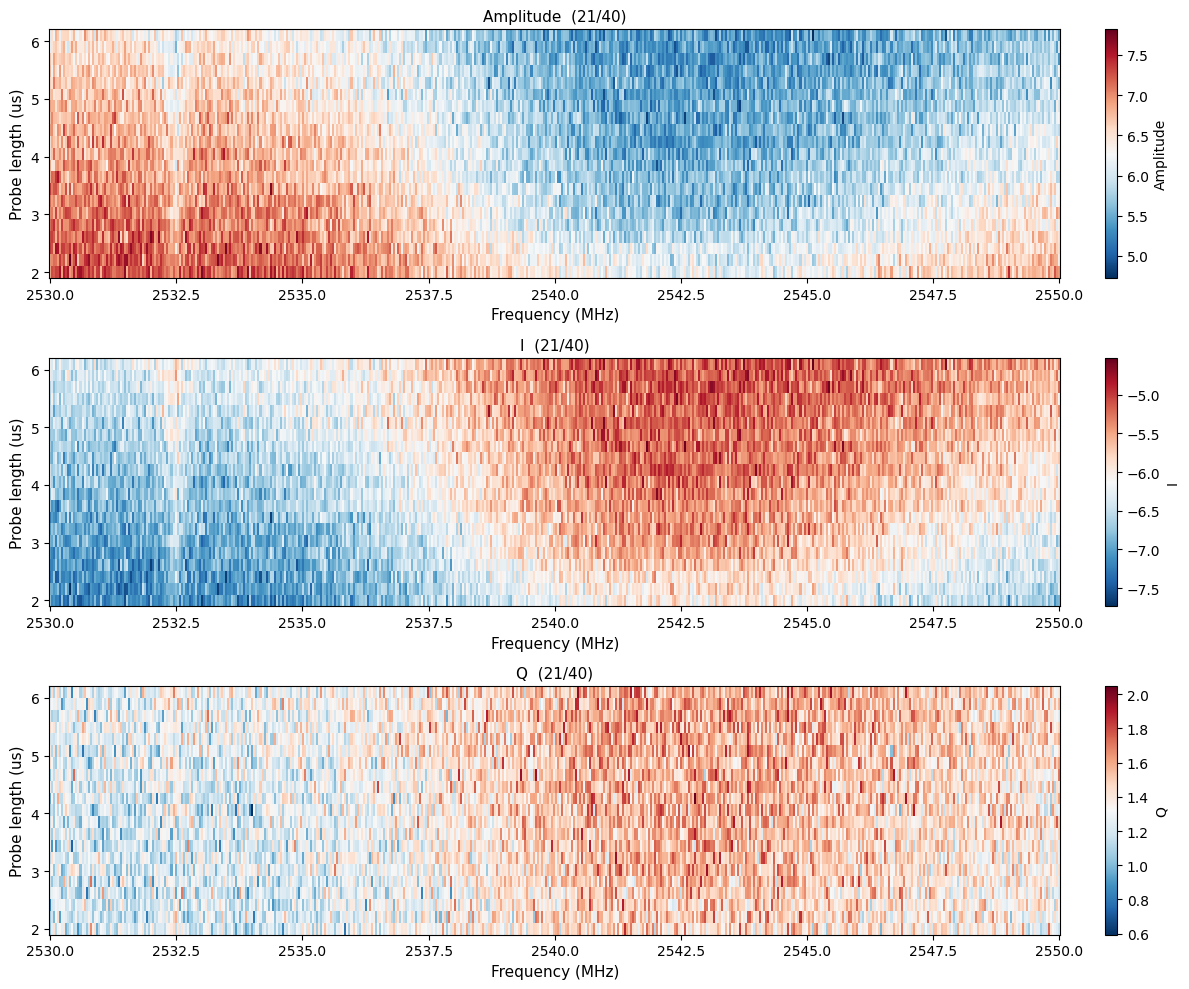

In [40]:
result = do_f0g1_length_sweep(
    config_thisrun  = config_thisrun,
    center          = 2540,
    span            = 20,
    expts           = 500,
    length_start    = 2.0,
    length_stop     = 10.0,
    length_n        = 40,
    reps            = 500,
    probe_gain      = 1.0,
    probe_chan      = config_thisrun.hw.soc.dacs.manipulate_in.ch,
    prepulse        = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse       = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
)



# re-plot with adjusted colorscale
replot_f0g1_length_sweep(result, clim={'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)})

## f0g1 length rabi 

In [33]:
from calibration_helpers import do_rabi

In [34]:
rabi_f0g1 = do_rabi(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    start               = 0.01,
    expts               = 300,
    reps                = 100,
    rounds              = 1,
    pulse_type          = 'flat_top',
    sweep               = 'length',
    chan                = config_thisrun.hw.soc.dacs.manipulate_in.ch,
    freq                = 2507,
    gain                = 1.0,
    sigma               = 0.05,
    sigma_inc           = 4,
    length              = 0.0,
    ramp_sigma          = 0.02,
    ramp_sigma_inc      = 0.0,
    n_pulses            = 1,
    prepulse            = {'pi_qubit_ge': {}, 'pi_qubit_ef': {}},
    postpulse           = {'pi_qubit_ef': {}, 'pi_qubit_ge': {}},
    max_gain            = 1.0,
    max_length          = 10.0,
    sweep_other_param   = {},
)

connected proxies, ns= <Pyro4.core.Proxy at 0x28550a1a810; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'start': 0.01, 'max_gain': 1.0, 'max_length': 10.0, 'expts': 300, 'reps': 100, 'rounds': 1, 'sigma_test': None, 'sweep': 'length', 'chan': 2, 'freq': 2507, 'type': 'flat_top', 'gain': 1.0, 'sigma': 0.05, 'step': 0.0333, 'sigma_inc': 4, 'length': 0.0, 'ramp_sigma': 0.02, 'ramp_sigma_inc': 0.0, 'prepulse': {'pi_qubit_ge': {}, 'pi_qubit_ef': {}}, 'postpulse': {'pi_qubit_ef': {}, 'pi_qubit_ge': {}}, 'n_pulses': 1, 'final_delay': 250, 'sweep_other_param': {}}
Configuring length sweep
{'length': {'label': 'rabi_pulse', 'param': 'length', 'param_type': 'pulse', 'start': 0.01, 'step': 0.0333, 'expts': 300}}
entering initialize sweep vars 
param name:  length
param values:  {'label': 'rabi_pulse', 'param': 'length', 'param_type': 'pulse', 'start': 0.01, 'step': 0.0333, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10,

  0%|          | 0/30000 [00:00<?, ?it/s]

Attempted to init fitparam 1 to 10.017391304347825, which is out of bounds 0.010051006711409398 to 5.025503355704698. Instead init to 2.5177771812080536
Attempted to init fitparam 4 to -7.408358882464324, which is out of bounds -0.28266811279826465 to 1.651062906724512. Instead init to 0.6841973969631236
Attempted to init fitparam 4 to 0.6841973969631236, which is out of bounds 5.250161659159753 to 9.534234171288247. Instead init to 7.392197915224


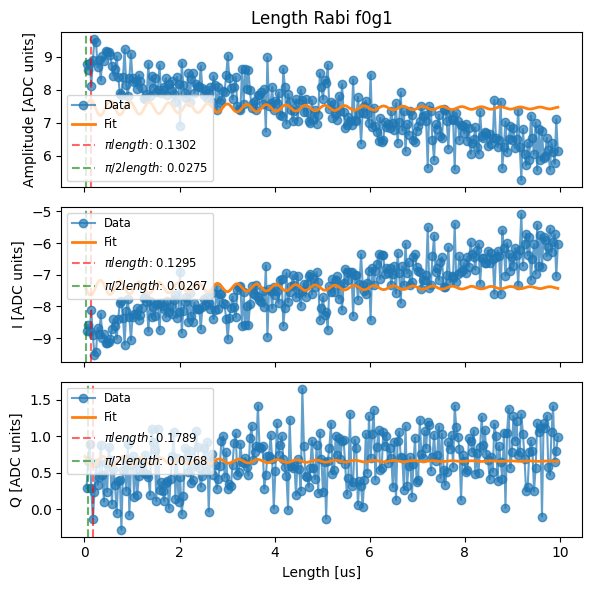

In [35]:
rabi_f0g1.analyze(fitparams = [None, None, None, None, None, None]) # [yscale, freq, phase_deg, decay, y0, x0]
rabi_f0g1.display(title_str='Length Rabi f0g1')

## Chevron Sweep — Coarse

In [ ]:
for man_mode_no in man_modes:
    center     = ds_thisrun.get_freq('M' + str(man_mode_no))
    freq_start = center - 3.0
    freq_stop  = center + 3.0
    freq_step  = 0.3
    print(f'Coarse chevron M{man_mode_no}: {freq_start:.3f} → {freq_stop:.3f} MHz')

    do_length_rabi_f0g1_sweep(
        config_thisrun = config_thisrun,
        expt_path      = expt_path,
        config_path    = config_path,
        freq_start     = freq_start,
        freq_stop      = freq_stop,
        freq_step      = freq_step,
        exp_param_file = exp_param_file,
    )

    update_length_rabi_f0g1_sweep(
        expt_path      = expt_path,
        config_thisrun = config_thisrun,
        ds_thisrun     = ds_thisrun,
        man_mode_no    = man_mode_no,
        prev_data_fn   = prev_data,
    )

## Chevron Sweep — Fine

In [ ]:
for man_mode_no in man_modes:
    center     = ds_thisrun.get_freq('M' + str(man_mode_no))
    freq_start = center - 0.3
    freq_stop  = center + 0.3
    freq_step  = 0.025
    print(f'Fine chevron M{man_mode_no}: {freq_start:.3f} → {freq_stop:.3f} MHz')

    do_length_rabi_f0g1_sweep(
        config_thisrun = config_thisrun,
        expt_path      = expt_path,
        config_path    = config_path,
        freq_start     = freq_start,
        freq_stop      = freq_stop,
        freq_step      = freq_step,
        exp_param_file = exp_param_file,
    )

    update_length_rabi_f0g1_sweep(
        expt_path      = expt_path,
        config_thisrun = config_thisrun,
        ds_thisrun     = ds_thisrun,
        man_mode_no    = man_mode_no,
        prev_data_fn   = prev_data,
    )

## Error Amplification — Frequency

In [ ]:
err_amp_freq = {}
for man_mode_no in man_modes:
    sideband    = 'f0-g1'
    _sideband   = 'fn-gn+1'
    i           = 0
    band        = 0.5
    expts_ea    = 20
    freq_center = config_thisrun.device.multiphoton['pi'][_sideband]['frequency'][i]
    freq_start  = freq_center - band
    step        = 2 * band / expts_ea
    print(f'Error amp freq M{man_mode_no}: center={freq_center:.4f} MHz')

    exp = do_error_amplification(
        config_thisrun      = config_thisrun,
        expt_path           = expt_path,
        config_path         = config_path,
        reps                = 100,
        rounds              = 1,
        qubit               = 0,
        n_pulses            = 7,
        active_reset        = False,
        man_reset           = True,
        storage_reset       = True,
        start               = freq_start,
        expts               = expts_ea,
        step                = step,
        parameter_to_test   = 'frequency',
        pulse_type          = ['multiphoton', sideband, 'pi', 0],
    )
    err_amp_freq[man_mode_no] = exp
    exp.analyze(state_fin='e')
    exp.display()

    config_thisrun.device.multiphoton['pi'][_sideband]['frequency'][i] = \
        exp.data['fit_avgi'][2]
    ds_thisrun.update_freq('M' + str(man_mode_no), exp.data['fit_avgi'][2])
    print(f'Updated M{man_mode_no} freq to {exp.data["fit_avgi"][2]:.4f} MHz')

## Length Rabi F0G1 — Update Pi Time

In [ ]:
len_rabis = {}
for man_mode_no in man_modes:
    print(f'Length rabi M{man_mode_no}')
    lr_analysis = do_length_rabi_f0g1_general(
        config_thisrun = config_thisrun,
        ds_thisrun     = ds_thisrun,
        expt_path      = expt_path,
        config_path    = config_path,
        man_mode_no    = man_mode_no,
    )
    len_rabis[man_mode_no] = lr_analysis

    update_length_rabi_f0g1_general(
        analysis    = lr_analysis,
        ds_thisrun  = ds_thisrun,
        man_mode_no = man_mode_no,
    )

In [ ]:
station.handle_config_update(write_to_file=True)
print('Config saved.')

## Find Manipulates through direct coupling to readout 

In [78]:
ramp_current_mA(dcflux, 0.05)

Ramping 0.0000 → 0.0500 mA  (0.01 mA/s, ETA 5.0s)
Done. Current: 0.0500 mA


In [79]:
from calibration_helpers import do_pulse_probe_spec
parspec =  do_pulse_probe_spec(
    config_thisrun,
    center= 3799.0,
    span=40,
    expts=100,
    reps=300,
    rounds=1,
    prepulse= {},#{"hpi_qubit_ge":{}},  # should be a dict
    postpulse= {},#{"hpi_qubit_ge":{},},  # should be a dict
    
    
    probe_pulse_param = {
    "gain": 0.1, #0.123,
    "length": 0.1, #0.2
    "freq": None,  # doesn't matter
    "chan": config_thisrun.hw.soc.dacs.manipulate_in.ch,
    "sigma": 0,
    "sigma_inc": 0,
    "ramp_sigma": None,
    "ramp_sigma_inc": None,
    "phase":0,
    "type": 'const',
    "t":0},
    analyze_and_display = False
)

connected proxies, ns= <Pyro4.core.Proxy at 0x28549d88a10; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 3779.0, 'step': 0.4, 'expts': 100, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 0.1, 'length': 0.1, 'freq': <qick.asm_v2.QickParam object at 0x0000028549E32E50>, 'chan': 2, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const', 't': 0}
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/30000 [00:00<?, ?it/s]

new display function for spectroscopy
Data 1 - Found peak in amps at 3799.550 MHz, HWHM 3.036
Data 1 - Found peak in avgi at 3799.584 MHz, HWHM 3.202
Data 1 - Found peak in avgq at 3799.663 MHz, HWHM 4.604


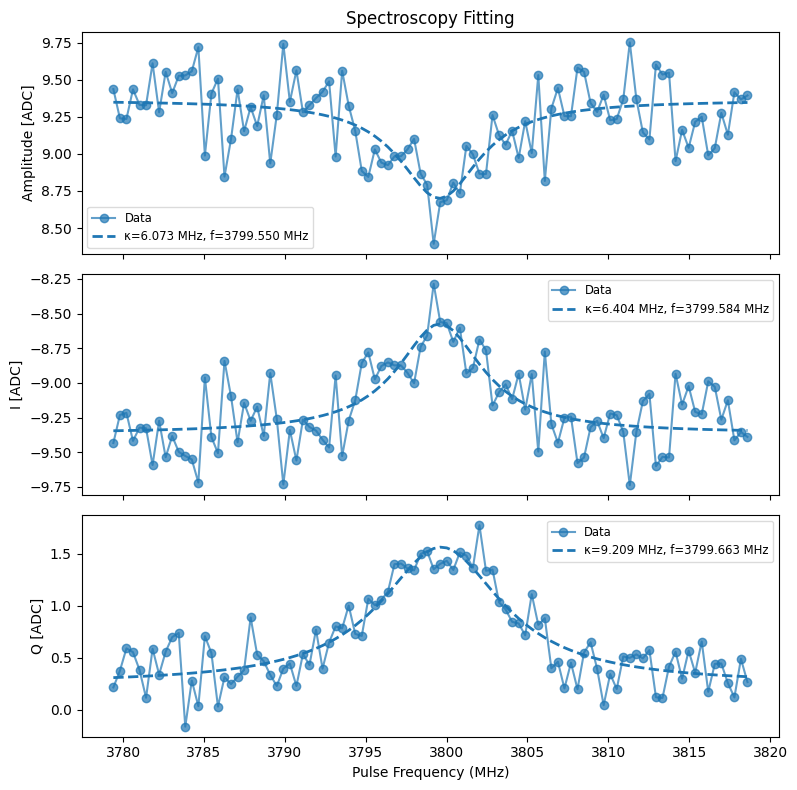

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_16-29-40_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_16-29-40_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


In [80]:
spec_analysis = meas.SpectroscopyFitting(station = station, data=parspec.data)
spec_analysis.analyze() #fitparams = [-0.7, -0.5, 3064.7, 10]) #[y0, yscale, x0, xscale]
spec_analysis.display()

### Readout chi to manipulate 

In [50]:
from calibration_helpers import do_res_spec

In [62]:
rspecs_chi = []
man_custom_pulse = {"man_pulse": {"freq": 3799.398,
                "gain": 0.1,
                "type": "const",
                "sigma": 0.0,
                "phase": 0,
                "chan": config_thisrun.hw.soc.dacs.manipulate_in.ch,
                "length": 0.1}}
# for pulse_man in [False, True]:
rspec = do_res_spec(
    config_thisrun                = config_thisrun,
    frequency                     = config_thisrun.device.readout.frequency,
    span                          = 20,
    expts                         = 300,
    reps                          = 100,
    rounds                        = 1,
    gain                          = config_thisrun.device.readout.gain,
    length                        = config_thisrun.device.readout.length,
    final_delay                   = 250,
    pulse_e                       = False,
    prepulse                      = man_custom_pulse,
    analyze_and_display           = False,
    use_config_params_for_readout = False,
)
rspecs_chi.append(rspec)


# chi_ge = rspecs_chi[1].data['fit_amps'][2] - rspecs_chi[0].data['fit_amps'][2]
# print(f'Chi_ge = {chi_ge:.3f} MHz')

connected proxies, ns= <Pyro4.core.Proxy at 0x28550f30890; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  frequency
param values:  {'label': 'readout_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 7590.419829610536, 'step': 0.06666666666666667, 'expts': 300}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': <qick.asm_v2.QickParam object at 0x000002854A1B0650>, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
Applied prepulse:  man_pulse
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/30000 [00:00<?, ?it/s]

Saving S:\Multimode\experiment\2600403_lmm\data\00354_ResonatorSpectroscopyExperiment.h5


new display function for spectroscopy
Data 1 - Found peak in amps at 7600.204 MHz, HWHM 0.864
Data 1 - Found peak in avgi at 7597.278 MHz, HWHM 0.062
Data 1 - Found peak in avgq at 7599.818 MHz, HWHM 0.024


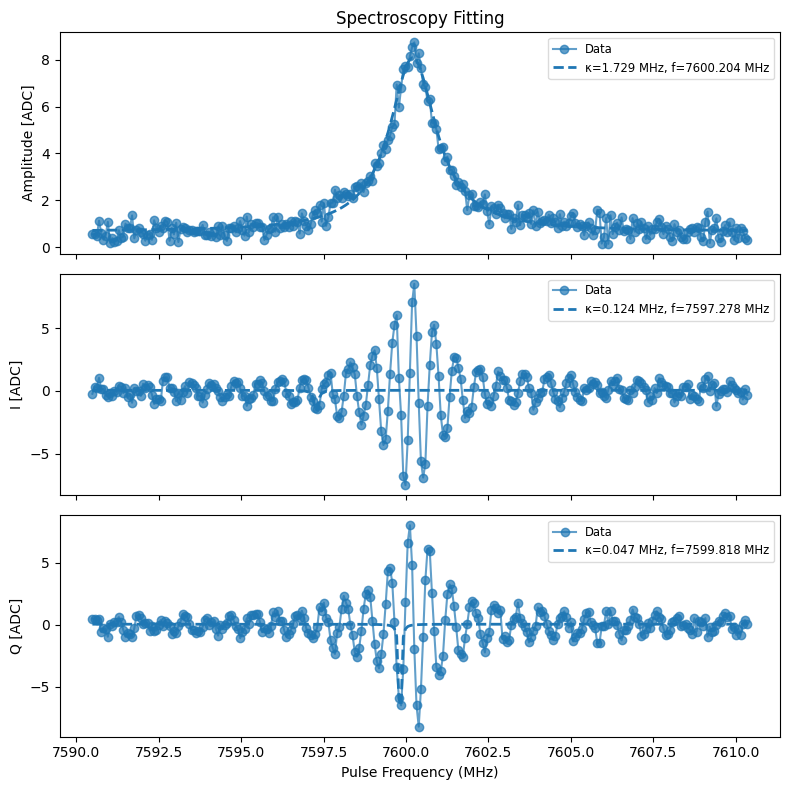

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-58-24_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_15-58-24_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


In [64]:
spec_analysis = meas.SpectroscopyFitting(station = station, data=rspec.data)
spec_analysis.analyze() #fitparams = [-0.7, -0.5, 3064.7, 10]) #[y0, yscale, x0, xscale]
spec_analysis.display()

### T1 using small displacements 

In [65]:
from calibration_helpers import do_t1

In [ ]:
config_thisrun.device.readout.final_delay = 2500 
station.handle_config_update(True)

Comparing configurations:
Key 'device.readout.final_delay' differs:
  Old value (config1): 500
  New value (config2): 2000
Configuration updated and saved, excluding storage_man_file.


connected proxies, ns= <Pyro4.core.Proxy at 0x2855103a210; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
{'wait_time': {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 10.0, 'expts': 200}}
entering initialize sweep vars 
param name:  wait_time
param values:  {'label': 'wait', 'param': 't', 'param_type': 'time', 'start': 0.01, 'step': 10.0, 'expts': 200}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
Applied prepulse:  man_pulse
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/20000 [00:00<?, ?it/s]

T1 (I): 546.021 us  ±  85.066 us
T1 (Q): 619.336 us  ±  70.061 us


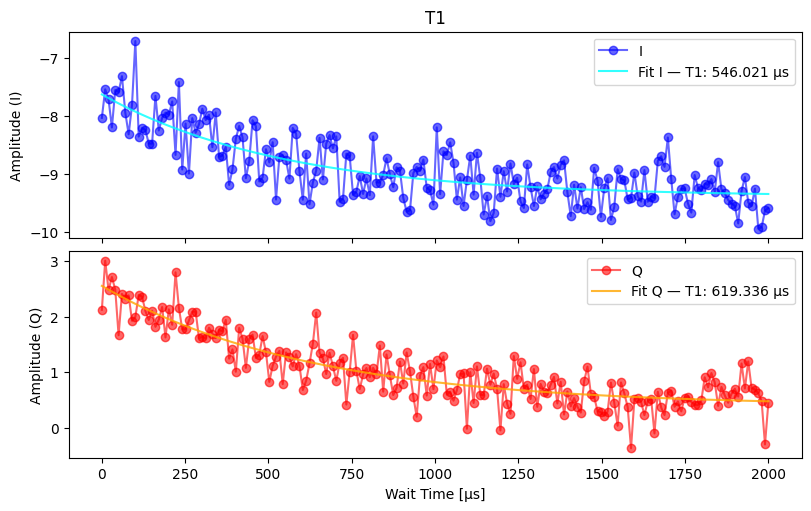

In [81]:
man_custom_pulse = {"man_pulse": {"freq": 3799.584,
                "gain": 0.15,           
                  "type": "const",
                  "sigma": 0.0,
                  "phase": 0,
                  "chan": config_thisrun.hw.soc.dacs.manipulate_in.ch,
                  "length": 0.1}}
do_t1(
    config_thisrun      = config_thisrun,
    cfg_dict            = cfg_dict,
    prepulse            = man_custom_pulse,
    start               = 0.01,
    step_size           = 10.0,
    expts               = 200,
    reps                = 100,
    rounds              = 1,
    analyze_and_display = True,
    qubit_pulse = False)

### Rf flux spec of displaced states

In [88]:
config_thisrun.hw.soc.dacs.flux.fc = 1000
config_thisrun.hw.soc.dacs.flux.bw = 1.0
station.handle_config_update(True)

Comparing configurations:
Key 'hw.soc.dacs.flux.fc' differs:
  Old value (config1): 500
  New value (config2): 1000
Configuration updated and saved, excluding storage_man_file.


In [ ]:
man_custom_pulse = {"man_pulse":    
            {"freq": 3799.584,
             "gain": 0.15,           
             "type": "const",
             "sigma": 0.0,
             "phase": 0,
             "chan": config_thisrun.hw.soc.dacs.manipulate_in.ch,
             "length": 0.1}}
rfspec =  do_pulse_probe_spec(
    config_thisrun,
    center= 1600.0,
    span=50,
    expts=500,
    reps=100,
    rounds=1,
    prepulse= man_custom_pulse,#{"hpi_qubit_ge":{}},  # should be a dict
    postpulse= {},#{"hpi_qubit_ge":{},},  # should be a dict
    
    
    probe_pulse_param = {
    "gain": 1.0, #0.123,
    "length": 5.0, #0.2
    "freq": None,  # doesn't matter
    "chan": config_thisrun.hw.soc.dacs.flux.ch,
    "sigma": 0,
    "sigma_inc": 0,
    "ramp_sigma": None,
    "ramp_sigma_inc": None,
    "phase":0,
    "type": 'const',
    "t":0},
    analyze_and_display = False
)

connected proxies, ns= <Pyro4.core.Proxy at 0x28549f09250; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 1575.0, 'step': 0.1, 'expts': 500, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': 1.0, 'length': 5.0, 'freq': <qick.asm_v2.QickParam object at 0x000002855159E4D0>, 'chan': 3, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const', 't': 0}
man_pulse
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/50000 [00:00<?, ?it/s]

In [100]:
4.8 - 3.8 

1.0

new display function for spectroscopy
Data 1 - Found peak in amps at 1590.204 MHz, HWHM -0.356
Data 1 - Found peak in avgi at 1583.128 MHz, HWHM 0.257
Data 1 - Found peak in avgq at 1584.791 MHz, HWHM -0.315


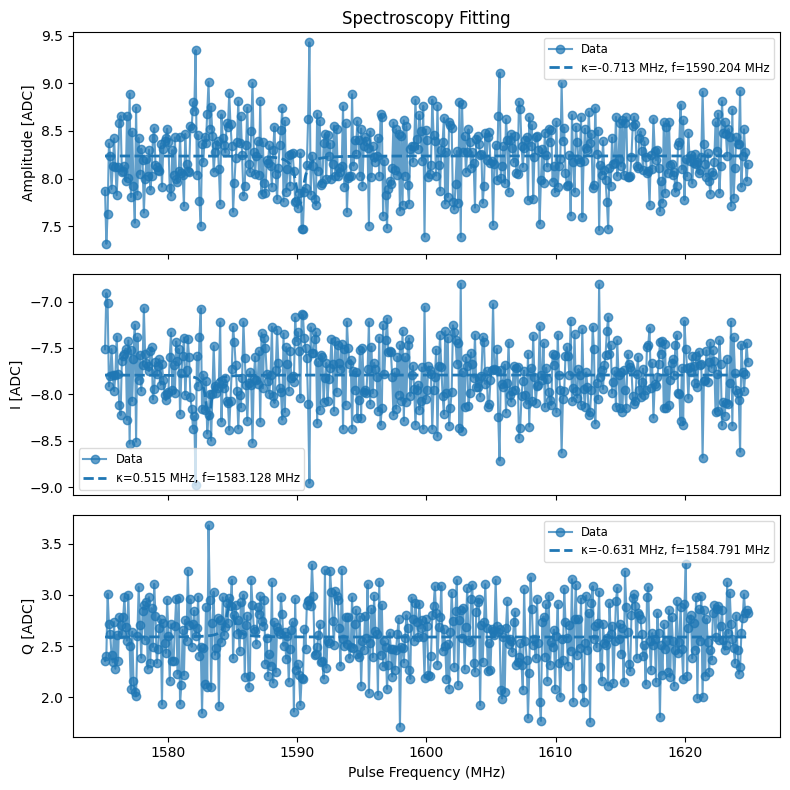

fname  S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_17-05-50_Spectroscopy_Fitting.png
Plot saved to S:\Multimode\experiment\2600403_lmm\plots\2026-04-14_17-05-50_Spectroscopy_Fitting.png
Plot reference appended to S:\Multimode\experiment\2600403_lmm\logs\2026-04-14.md


In [99]:
spec_analysis = meas.SpectroscopyFitting(station = station, data=rfspec.data)
spec_analysis.analyze() #fitparams = [-0.7, -0.5, 3064.7, 10]) #[y0, yscale, x0, xscale]
spec_analysis.display()

### RF spec length and gain sweep 

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output


# ── shared internals ──────────────────────────────────────────────────────────

def _run_rfspec(config_thisrun, man_custom_pulse, center, span, expts, reps,
                rounds, probe_gain, probe_length, probe_chan,
                max_retries, retry_delay_s):
    """Run a single rfspec point with retry on worker error."""
    for attempt in range(max_retries):
        try:
            pspec = do_pulse_probe_spec(
                config_thisrun      = config_thisrun,
                center              = center,
                span                = span,
                expts               = expts,
                reps                = reps,
                rounds              = rounds,
                pulse_e             = False,
                prepulse            = man_custom_pulse,
                postpulse           = {},
                sweep_other_param   = None,
                probe_pulse_param   = {
                    'gain':           probe_gain,
                    'length':         probe_length,
                    'freq':           None,
                    'chan':           probe_chan,
                    'sigma':          0,
                    'sigma_inc':      0,
                    'ramp_sigma':     None,
                    'ramp_sigma_inc': None,
                    'phase':          0,
                    'type':           'const',
                    't':              0,
                },
                analyze_and_display = False,
            )
            time.sleep(30)
            return pspec

        except Exception as e:
            if 'no free workers' in str(e) and attempt < max_retries - 1:
                print(f'  Worker busy (attempt {attempt+1}/{max_retries}), '
                      f'retrying in {retry_delay_s}s...')
                time.sleep(retry_delay_s)
            else:
                print(f'  Failed after {max_retries} attempts: {e}')
                return None


def _live_plot(fig, axes, cbars, freq_array, sweep_vals, matrices, titles,
               ylabel, filled, n_total, cmap):
    for ax in axes:
        ax.cla()
    for j, (ax, mat, title) in enumerate(zip(axes, matrices, titles)):
        im = ax.pcolormesh(freq_array, sweep_vals[:filled], mat[:filled],
                           shading='auto', cmap=cmap)
        ax.set_xlabel('Frequency (MHz)', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{title}  ({filled}/{n_total})', fontsize=11)
        if cbars[j] is None:
            cbars[j] = fig.colorbar(im, ax=ax, label=title,
                                    fraction=0.046, pad=0.04)
        else:
            cbars[j].update_normal(im)
    fig.tight_layout()
    clear_output(wait=True)
    display(fig)


def _replot(sweep_vals, freq_array, matrices, keys, titles, xlabel, ylabel,
            cmap, clim, figsize, sweep_label):
    if clim is None:
        clims = {k: None for k in keys}
    elif isinstance(clim, tuple):
        clims = {k: clim for k in keys}
    else:
        clims = clim

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharey=True)
    for ax, mat, key, title in zip(axes, matrices, keys, titles):
        im = ax.pcolormesh(freq_array, sweep_vals, mat, shading='auto', cmap=cmap)
        if clims.get(key) is not None:
            im.set_clim(*clims[key])
        fig.colorbar(im, ax=ax, label=title, fraction=0.046, pad=0.04)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_title(f'RF spec {sweep_label} sweep — {title}', fontsize=11)
    axes[0].set_ylabel(ylabel, fontsize=11)
    fig.tight_layout()
    plt.show()
    return fig


# ── gain sweep ────────────────────────────────────────────────────────────────

def do_rfspec_gain_sweep(
    config_thisrun,
    # manipulate prepulse (fixed across sweep)
    man_freq            = 3799.584,
    man_gain            = 0.15,
    man_length          = 0.1,
    man_chan            = None,     # defaults to config_thisrun.hw.soc.dacs.manipulate_in.ch
    # frequency axis
    center              = 1600.0,
    span                = 50,
    expts               = 500,
    # gain sweep
    gains               = None,
    gain_start          = 0.1,
    gain_stop           = 1.0,
    gain_n              = 20,
    # per-point params (fixed)
    reps                = 100,
    rounds              = 1,
    probe_length        = 5.0,
    probe_chan          = None,     # defaults to config_thisrun.hw.soc.dacs.flux.ch
    # display
    cmap                = 'RdBu_r',
    figsize             = (12, 12),
    # retry
    max_retries         = 5,
    retry_delay_s       = 3.0,
):
    """
    Gain sweep of RF spectroscopy (flux probe) with fixed manipulate prepulse.
    Live 2D colorplot of amps, I, Q vs probe gain.

    Returns
    -------
    dict: gains, freq_array, amp_matrix, i_matrix, q_matrix, pspecs
    """
    if gains is None:
        gains = np.linspace(gain_start, gain_stop, gain_n)
    gains = np.asarray(gains)

    if man_chan   is None: man_chan   = config_thisrun.hw.soc.dacs.manipulate_in.ch
    if probe_chan is None: probe_chan = config_thisrun.hw.soc.dacs.flux.ch

    man_pulse = {'man_pulse': {
        'freq': man_freq, 'gain': man_gain, 'type': 'const',
        'sigma': 0.0, 'phase': 0, 'chan': man_chan, 'length': man_length,
    }}

    n         = len(gains)
    pspecs    = {}
    amp_matrix = i_matrix = q_matrix = freq_array = None

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharey=False)
    plt.ion()
    cbars = [None, None, None]

    try:
        for idx, gain in enumerate(gains):
            print(f'\n[{idx+1}/{n}]  probe gain = {gain:.4f}')
            pspec = _run_rfspec(config_thisrun, man_pulse, center, span, expts,
                                reps, rounds, gain, probe_length, probe_chan,
                                max_retries, retry_delay_s)
            pspecs[float(gain)] = pspec

            if pspec is None:
                n_pts  = len(freq_array) if freq_array is not None else expts
                r_amps = r_avgi = r_avgq = np.full(n_pts, np.nan)
            else:
                freq_array = pspec.data['xpts']
                def _row(k):
                    r = np.array(pspec.data[k])
                    return r.flatten() if r.ndim > 1 else r
                r_amps, r_avgi, r_avgq = _row('amps'), _row('avgi'), _row('avgq')

            def _stack(mat, row):
                return row[np.newaxis, :] if mat is None else np.vstack([mat, row])
            amp_matrix = _stack(amp_matrix, r_amps)
            i_matrix   = _stack(i_matrix,   r_avgi)
            q_matrix   = _stack(q_matrix,   r_avgq)

            _live_plot(fig, axes, cbars, freq_array, gains,
                       [amp_matrix, i_matrix, q_matrix],
                       ['Amplitude', 'I', 'Q'],
                       'Probe gain', idx+1, n, cmap)

    except KeyboardInterrupt:
        print('\nInterrupted.')

    plt.ioff()
    n_ok = sum(1 for sp in pspecs.values() if sp is not None)
    print(f'\nDone. {n_ok}/{n} points acquired.')
    return dict(gains=gains, freq_array=freq_array,
                amp_matrix=amp_matrix, i_matrix=i_matrix,
                q_matrix=q_matrix, pspecs=pspecs)


def replot_rfspec_gain_sweep(result, cmap='RdBu_r', clim=None, figsize=(16, 5)):
    _replot(result['gains'], result['freq_array'],
            [result['amp_matrix'], result['i_matrix'], result['q_matrix']],
            ['amps', 'avgi', 'avgq'], ['Amplitude', 'I', 'Q'],
            'Frequency (MHz)', 'Probe gain', cmap, clim, figsize, 'gain')


# ── length sweep ──────────────────────────────────────────────────────────────

def do_rfspec_length_sweep(
    config_thisrun,
    # manipulate prepulse (fixed across sweep)
    man_freq            = 3799.584,
    man_gain            = 0.15,
    man_length          = 0.1,
    man_chan            = None,
    # frequency axis
    center              = 1600.0,
    span                = 50,
    expts               = 500,
    # length sweep
    lengths             = None,
    length_start        = 0.1,
    length_stop         = 10.0,
    length_n            = 20,
    # per-point params (fixed)
    reps                = 100,
    rounds              = 1,
    probe_gain          = 1.0,
    probe_chan          = None,
    # display
    cmap                = 'RdBu_r',
    figsize             = (12, 12),
    # retry
    max_retries         = 5,
    retry_delay_s       = 3.0,
):
    """
    Length sweep of RF spectroscopy (flux probe) with fixed manipulate prepulse.
    Live 2D colorplot of amps, I, Q vs probe length.

    Returns
    -------
    dict: lengths, freq_array, amp_matrix, i_matrix, q_matrix, pspecs
    """
    if lengths is None:
        lengths = np.linspace(length_start, length_stop, length_n)
    lengths = np.asarray(lengths)

    if man_chan   is None: man_chan   = config_thisrun.hw.soc.dacs.manipulate_in.ch
    if probe_chan is None: probe_chan = config_thisrun.hw.soc.dacs.flux.ch

    man_pulse = {'man_pulse': {
        'freq': man_freq, 'gain': man_gain, 'type': 'const',
        'sigma': 0.0, 'phase': 0, 'chan': man_chan, 'length': man_length,
    }}

    n          = len(lengths)
    pspecs     = {}
    amp_matrix = i_matrix = q_matrix = freq_array = None

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharey=False)
    plt.ion()
    cbars = [None, None, None]

    try:
        for idx, length in enumerate(lengths):
            print(f'\n[{idx+1}/{n}]  probe length = {length:.4f} us')
            pspec = _run_rfspec(config_thisrun, man_pulse, center, span, expts,
                                reps, rounds, probe_gain, length, probe_chan,
                                max_retries, retry_delay_s)
            pspecs[float(length)] = pspec

            if pspec is None:
                n_pts  = len(freq_array) if freq_array is not None else expts
                r_amps = r_avgi = r_avgq = np.full(n_pts, np.nan)
            else:
                freq_array = pspec.data['xpts']
                def _row(k):
                    r = np.array(pspec.data[k])
                    return r.flatten() if r.ndim > 1 else r
                r_amps, r_avgi, r_avgq = _row('amps'), _row('avgi'), _row('avgq')

            def _stack(mat, row):
                return row[np.newaxis, :] if mat is None else np.vstack([mat, row])
            amp_matrix = _stack(amp_matrix, r_amps)
            i_matrix   = _stack(i_matrix,   r_avgi)
            q_matrix   = _stack(q_matrix,   r_avgq)

            _live_plot(fig, axes, cbars, freq_array, lengths,
                       [amp_matrix, i_matrix, q_matrix],
                       ['Amplitude', 'I', 'Q'],
                       'Probe length (us)', idx+1, n, cmap)

    except KeyboardInterrupt:
        print('\nInterrupted.')

    plt.ioff()
    n_ok = sum(1 for sp in pspecs.values() if sp is not None)
    print(f'\nDone. {n_ok}/{n} points acquired.')
    return dict(lengths=lengths, freq_array=freq_array,
                amp_matrix=amp_matrix, i_matrix=i_matrix,
                q_matrix=q_matrix, pspecs=pspecs)


def replot_rfspec_length_sweep(result, cmap='RdBu_r', clim=None, figsize=(16, 5)):
    _replot(result['lengths'], result['freq_array'],
            [result['amp_matrix'], result['i_matrix'], result['q_matrix']],
            ['amps', 'avgi', 'avgq'], ['Amplitude', 'I', 'Q'],
            'Frequency (MHz)', 'Probe length (us)', cmap, clim, figsize, 'length')

In [6]:
config_thisrun.hw.soc.dacs.flux.fc = 1000 
config_thisrun.hw.soc.dacs.flux.bw = 2.0 
station.handle_config_update(True)

Comparing configurations:
Key 'hw.soc.dacs.flux.bw' differs:
  Old value (config1): 1.0
  New value (config2): 2.0
Configuration updated and saved, excluding storage_man_file.


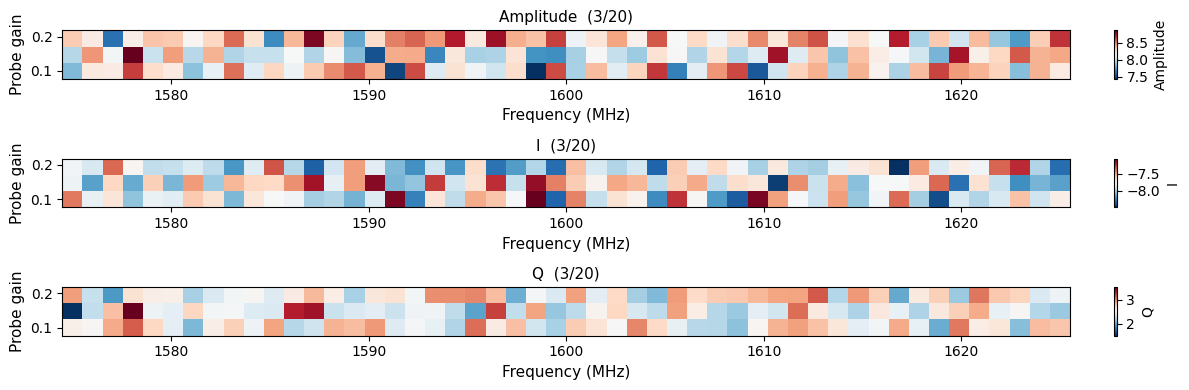


[4/20]  probe gain = 0.2421
connected proxies, ns= <Pyro4.core.Proxy at 0x23ac0f73110; connected IPv4; for PYRO:Pyro.NameServer@localhost:9090>
entering initialize sweep vars 
param name:  freq
param values:  {'label': 'probe_pulse', 'param': 'freq', 'param_type': 'pulse', 'start': 1575.0, 'step': 1.0, 'expts': 50, 'parent_dict': 'probe_pulse_param'}
pulse_args in initialize_readout {'ch': 1, 'name': 'readout_pulse', 'style': 'const', 'ro_ch': 10, 'freq': 7600.419829610536, 'phase': 46.71898553353748, 'gain': 0.2, 'length': 3}
922
307.2
making probe pulse with parameters:  {'gain': np.float64(0.24210526315789474), 'length': 5.0, 'freq': <qick.asm_v2.QickParam object at 0x0000023AC0F06750>, 'chan': 3, 'sigma': 0, 'sigma_inc': 0, 'ramp_sigma': None, 'ramp_sigma_inc': None, 'phase': 0, 'type': 'const', 't': 0}
man_pulse
pulsing resonator
triggering readout at time 0.5
10
430.08


  0%|          | 0/5000 [00:00<?, ?it/s]


Interrupted.

Done. 3/20 points acquired.


TypeError: Dimensions of C (3, 50) should be one smaller than X(50) and Y(20) while using shading='flat' see help(pcolormesh)

In [ ]:
# gain sweep — vary probe flux pulse gain, fixed man prepulse
result = do_rfspec_gain_sweep(
    config_thisrun  = config_thisrun,
    man_freq        = 3799.584,
    man_gain        = 0.15,
    man_length      = 0.1,
    man_chan        = config_thisrun.hw.soc.dacs.manipulate_in.ch,
    center          = 1000.0,
    span            = 1800,
    expts           = 3600,
    gain_start      = 0.1,
    gain_stop       = 1.0,
    gain_n          = 20,
    reps            = 200,
    probe_length    = 5.0,
    probe_chan      = config_thisrun.hw.soc.dacs.flux.ch,
)

# length sweep — vary probe flux pulse length, fixed man prepulse
result = do_rfspec_length_sweep(
    config_thisrun  = config_thisrun,
    man_freq        = 3799.584,
    man_gain        = 0.15,
    man_length      = 0.1,
    center          = 1000.0,
    span            = 1800,
    expts           = 3600,
    length_start    = 0.5,
    length_stop     = 20.0,
    length_n        = 30,
    reps            = 200,
    probe_gain      = 1.0,
)

# replot with colorscale
replot_rfspec_gain_sweep(result, clim={'amps': (0, 5), 'avgi': (-2, 2), 'avgq': (-2, 2)})
# replot_rfspec_length_sweep(result, clim=(-2, 2))